# 1. Python, NumPy and pandas for machine learning

Every notebook in this course is written in Python, and almost every line of those
notebooks manipulates one of two objects: a **NumPy array** (a rectangular block of numbers)
or a **pandas DataFrame** (a table with named columns and a row index). Machine-learning
models consume arrays — a feature matrix $\mathbf{X}$ of shape $(n, d)$ and a target vector
$\mathbf{y}$ of length $n$ — and real data arrives as tables. Being fluent in both, and in
the conversion from one to the other, is what makes the rest of the course *readable*: when
notebook 6 writes `X.T @ X` or notebook 4 writes `df.groupby("contract")["churned"].mean()`,
you should see immediately what happens and what shape comes out.

This notebook is a fast but thorough refresher. It assumes you know basic Python
(variables, functions, lists, dictionaries, loops) and have perhaps seen NumPy once. It is
*not* a complete tutorial on either library — the references at the end point to those — but
it covers everything the course actually uses, with an emphasis on the ideas people find
hard: shapes and axes, broadcasting, views versus copies, index alignment, and the
performance model that makes vectorised code fast.

**Prerequisites:** notebook 0 (environment set up, Jupyter running). No mathematics beyond
high-school algebra is needed; notebook 2 covers the linear algebra we only *use* here.

## Learning objectives

After working through this notebook you will be able to

- explain why vectorised NumPy code is 10–100× faster than Python loops, and measure it;
- create arrays, reason about their `shape`, `dtype` and memory, and predict the result of any indexing expression (slices, boolean masks, fancy indexing) — including whether it returns a view or a copy;
- apply the broadcasting rule to write loop-free code such as column standardisation and a pairwise distance matrix;
- use `np.linalg` correctly (`solve` rather than `inv`, `lstsq`, `norm`, `svd`, `eigh`) and fit a least-squares line by hand;
- generate reproducible random numbers with `np.random.default_rng`, including permutations and bootstrap resamples;
- load, inspect, select, filter, transform, group, pivot, merge and chain operations on a pandas DataFrame, and handle missing values, dates and categorical columns;
- convert a DataFrame into the `X`/`y` arrays that scikit-learn expects and make a first stratified train/test split;
- avoid the classic performance and correctness pitfalls (`iterrows`, chained assignment, `object` columns).

## Setup

In [43]:
import sys    # access to the Python interpreter (used here for its version string and for object sizes)
import time   # time.perf_counter() is a high-resolution clock for benchmarking

import numpy as np                 # arrays and fast numerical maths
import pandas as pd                # DataFrames: labelled tables built on top of NumPy
import matplotlib.pyplot as plt    # the plotting library behind every figure in the course
import seaborn as sns              # statistical plots on top of matplotlib (used for the heatmap in section 6)

# course helpers: set_style() applies the shared plot style, PALETTE is the list of course colours
from course_utils import set_style, PALETTE

RANDOM_STATE = 42                          # one fixed seed so every run produces the same random numbers
rng = np.random.default_rng(RANDOM_STATE)  # a seeded random-number generator (section 5 explains it)
set_style()                                # apply the course-wide matplotlib settings once

# sys.version is a long string like "3.11.16 (main, ...)"; .split()[0] keeps only the version number
print(f"Python {sys.version.split()[0]} | NumPy {np.__version__} | pandas {pd.__version__}")

Python 3.11.16 | NumPy 2.4.6 | pandas 3.0.6


## 1. Why NumPy: vectorisation, memory layout and dtypes

A Python list is a flexible container: every element is a full Python object (a `float`
occupies 24 bytes and lives somewhere on the heap), and the list stores pointers to them.
Adding two lists element-wise means a Python-level loop that, for each pair, follows two
pointers, checks both types, allocates a new object and stores a pointer to it. A NumPy
array (Harris et al., 2020) is the opposite design: one contiguous block of memory holding
raw numbers of a single type (the **dtype**), plus a small header with the shape and the
strides. Element-wise operations are executed by compiled C loops over that block, and the
CPU can stream through it with its caches and vector instructions fully engaged.

This is what **vectorisation** means: expressing a computation as whole-array operations so
that the loop runs in C rather than in Python. It is not merely a stylistic preference —
the speed difference is one to two orders of magnitude, and it decides whether an experiment
takes a second or a minute. Let us measure it. We time with `time.perf_counter` and keep the
best of several runs, which is more robust than a single measurement (the first call often
pays a one-off warm-up cost).

In [44]:
def time_ms(fn, repeats=5):
    """Best-of-`repeats` wall-clock time of fn() in milliseconds.

    Calls the zero-argument function `fn` several times and keeps the fastest run,
    because the minimum is the measurement least disturbed by other programs.
    """
    best = float("inf")                            # start at "infinitely slow" so the first run always wins
    for _ in range(repeats):
        t0 = time.perf_counter()                   # timestamp in seconds, before the call
        fn()
        best = min(best, time.perf_counter() - t0)
    return best * 1e3                              # seconds -> milliseconds

values = [float(v) for v in range(1_000_000)]      # a plain Python list of one million floats
arr = np.arange(1_000_000, dtype=np.float64)       # the same numbers as one NumPy array

def sum_of_squares_loop(xs):
    """Return xs[0]**2 + xs[1]**2 + ... with an explicit Python loop (the slow baseline)."""
    total = 0.0
    for x in xs:                                   # the interpreter handles one element per iteration
        total += x * x
    return total

# `lambda: ...` wraps each expression in a zero-argument function, so time_ms can call it repeatedly
t_loop = time_ms(lambda: sum_of_squares_loop(values))
t_gen = time_ms(lambda: sum(x * x for x in values))     # built-in sum() over a generator: still one element at a time
t_np = time_ms(lambda: np.sum(arr * arr))               # arr * arr squares every element in compiled code, np.sum adds them

# the format spec {t:8.2f} means: width 8, two digits after the decimal point
print(f"Python for-loop           {t_loop:8.2f} ms")
print(f"generator expression      {t_gen:8.2f} ms")
print(f"NumPy  np.sum(arr * arr)  {t_np:8.2f} ms   ({t_loop / t_np:5.0f}x faster than the loop)")

Python for-loop              16.54 ms
generator expression         21.21 ms
NumPy  np.sum(arr * arr)      1.13 ms   (   15x faster than the loop)


The exact numbers depend on your machine, but the gap between the Python loop and the
NumPy versions is always one to two orders of magnitude, and it grows with the size of the
data. Note that `np.sum(arr * arr)` makes *two* passes over memory — one to build the
temporary array `arr * arr`, one to sum it. Fused routines such as `arr @ arr` (a dot
product, handed to the BLAS library) avoid the temporary altogether; *avoid temporaries,
prefer a single fused operation* is a pattern that recurs throughout numerical code and
matters most when arrays no longer fit in the CPU cache.

Memory tells the same story:

In [45]:
# sys.getsizeof(obj) is the memory one Python object uses, in bytes. A list only stores pointers; every
# float it points to is a separate object, so we add those too (measured on the first 1000, then scaled up)
list_bytes = sys.getsizeof(values) + sum(sys.getsizeof(v) for v in values[:1000]) * (len(values) // 1000)
print(f"list of 1e6 floats : {list_bytes / 1e6:6.1f} MB  (pointer array + one 24-byte object per float)")
# .nbytes is the size of an array's data buffer; .astype(dtype) returns a copy converted to another type
print(f"float64 array      : {arr.nbytes / 1e6:6.1f} MB  (8 bytes per element)")
print(f"float32 array      : {arr.astype(np.float32).nbytes / 1e6:6.1f} MB")
print(f"int8 array         : {arr.astype(np.int8).nbytes / 1e6:6.1f} MB  (but only holds -128..127!)")

list of 1e6 floats :   32.4 MB  (pointer array + one 24-byte object per float)
float64 array      :    8.0 MB  (8 bytes per element)
float32 array      :    4.0 MB
int8 array         :    1.0 MB  (but only holds -128..127!)


Both measurements are easier to judge side by side than as two columns of numbers. Note the
logarithmic axes: on a linear scale the NumPy bars would be invisible.

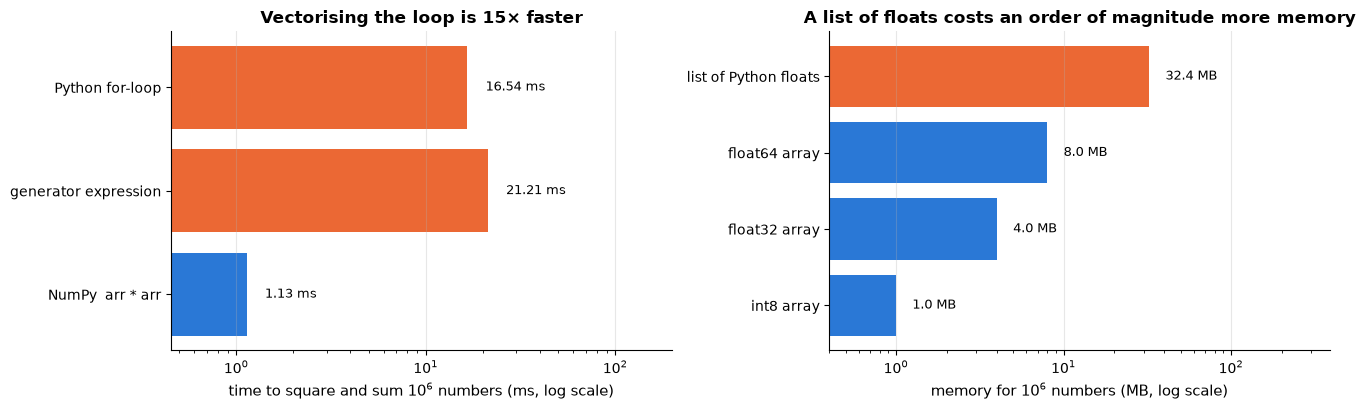

In [46]:
# plt.subplots(rows, cols) creates a figure plus a grid of axes (plot panels); figsize is in inches
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.2))

# --- left panel: the run times measured above
time_labels = ["Python for-loop", "generator expression", "NumPy  arr * arr"]
times = [t_loop, t_gen, t_np]
colours = [PALETTE[1], PALETTE[1], PALETTE[0]]       # orange for the pure-Python versions, blue for NumPy
axes[0].barh(time_labels, times, color=colours)      # barh draws horizontal bars: one label and one length per bar
for i, t in enumerate(times):                        # enumerate yields (position, value) pairs
    axes[0].text(t * 1.25, i, f"{t:.2f} ms", va="center", fontsize=9)   # write each value just right of its bar
axes[0].set_xscale("log")                            # log axis, because the times differ by more than 10x
axes[0].set_xlim(t_np * 0.4, t_loop * 12)            # leave room on the right for the text labels
axes[0].set_xlabel("time to square and sum $10^6$ numbers (ms, log scale)")
axes[0].set_title(f"Vectorising the loop is {t_loop / t_np:.0f}× faster")

# --- right panel: the memory footprints from the previous cell, converted from bytes to MB
mem_labels = ["list of Python floats", "float64 array", "float32 array", "int8 array"]
mem = [list_bytes / 1e6, arr.nbytes / 1e6, arr.astype(np.float32).nbytes / 1e6, arr.astype(np.int8).nbytes / 1e6]
axes[1].barh(mem_labels, mem, color=[PALETTE[1]] + [PALETTE[0]] * 3)
for i, m in enumerate(mem):
    axes[1].text(m * 1.25, i, f"{m:.1f} MB", va="center", fontsize=9)
axes[1].set_xscale("log")
axes[1].set_xlim(min(mem) * 0.4, max(mem) * 12)
axes[1].set_xlabel("memory for $10^6$ numbers (MB, log scale)")
axes[1].set_title("A list of floats costs an order of magnitude more memory")
for ax in axes:
    ax.invert_yaxis()                       # put the first label at the top instead of the bottom
    ax.grid(axis="y", visible=False)        # horizontal grid lines add nothing to a bar chart of categories
plt.tight_layout()                          # adjust spacing so titles and labels do not overlap
plt.show()                                  # render the figure

### 1.1 dtypes

Every array has exactly one `dtype`. The common ones are `float64` (the default for
decimals and the workhorse of scientific computing), `float32` (half the memory, the default
in deep learning), `int64`, `bool`, and, less usefully, fixed-width strings.
NumPy infers the dtype from the data and **upcasts** when types are mixed; it does *not*
protect you from overflow in small integer types, and floating-point numbers have finite
precision. Three facts worth knowing:

In [47]:
# np.array(list) builds an array and infers one dtype (element type) that fits all the elements
print("inferred dtypes  :", np.array([1, 2, 3]).dtype, "|", np.array([1, 2.5]).dtype, "|", np.array([True, False]).dtype)
# mixing types in arithmetic promotes ("upcasts") the result to a type that can hold both
print("upcasting        :", (np.array([1, 2]) + 0.5).dtype, "(int + float -> float)")

small = np.array([100, 100], dtype=np.int8)     # int8: 1 byte per element, values -128..127 only
print("int8 overflow    :", small + small, "(silently wraps around: 200 does not fit in int8)")

# float32 has a 24-bit mantissa, so above 2**24 = 16_777_216 it can no longer represent every integer
print("float32 precision:", np.float32(16_777_216) + np.float32(1) == np.float32(16_777_216),
      "(1e7 + 1 == 1e7 in float32: only ~7 significant digits)")
# 0.1 and 0.2 have no exact binary representation, so 0.1 + 0.2 is 0.30000000000000004
print("float64 rounding :", 0.1 + 0.2 == 0.3, "-> compare floats with np.isclose / np.allclose")

# memory layout: one contiguous buffer, C order, strides in bytes
X = np.arange(12, dtype=np.float64).reshape(3, 4)    # the numbers 0..11 arranged as 3 rows x 4 columns
print("\nX =\n", X)
# shape: length of each axis | ndim: number of axes | size: total number of elements | itemsize: bytes per element
print("shape", X.shape, "| ndim", X.ndim, "| size", X.size, "| itemsize", X.itemsize, "bytes")
print("strides (bytes to the next row, next column):", X.strides)
# X.T (the transpose) swaps the strides instead of moving data;
# np.shares_memory(a, b) is True when two arrays use the same underlying buffer
print("transposed strides:", X.T.strides, "-> same buffer, no copy:", np.shares_memory(X, X.T))

inferred dtypes  : int64 | float64 | bool
upcasting        : float64 (int + float -> float)
int8 overflow    : [-56 -56] (silently wraps around: 200 does not fit in int8)
float32 precision: True (1e7 + 1 == 1e7 in float32: only ~7 significant digits)
float64 rounding : False -> compare floats with np.isclose / np.allclose

X =
 [[ 0.  1.  2.  3.]
 [ 4.  5.  6.  7.]
 [ 8.  9. 10. 11.]]
shape (3, 4) | ndim 2 | size 12 | itemsize 8 bytes
strides (bytes to the next row, next column): (32, 8)
transposed strides: (8, 32) -> same buffer, no copy: True


> **Warning.** Never test floating-point results with `==`. Use `np.isclose(a, b)` or
> `np.allclose(A, B)` (default tolerances `rtol=1e-5`, `atol=1e-8`), as we do throughout the
> course whenever we check a from-scratch implementation against a library.

### 1.2 Memory layout

The second half of the cell above shows the memory layout. An array's data live in one
contiguous buffer, by default in **C order** (row-major: the last index varies fastest, so
the elements of a row are neighbours in memory). The `strides` say how many bytes to jump
to move one step along each axis — 32 bytes to the next row, 8 to the next column for a
`(3, 4)` float64 array. Row-major layout has a practical consequence: iterating over rows
(`for row in X`) or reducing along axis 1 touches consecutive memory and is fast, whereas
striding down a column skips over whole rows. NumPy handles all of this for you, but it
explains why transposes are free (`X.T` just swaps the strides — no data are copied) and
why some operations are faster along one axis than the other.

The picture below makes the idea concrete. The same 3 × 4 matrix of values is shown twice;
each cell is coloured and labelled by the **position its value occupies in the flat memory
buffer**, and the buffer itself is drawn underneath. In C order the elements of a row are
consecutive; in Fortran order the elements of a *column* are. The values are identical — only
the strides differ.

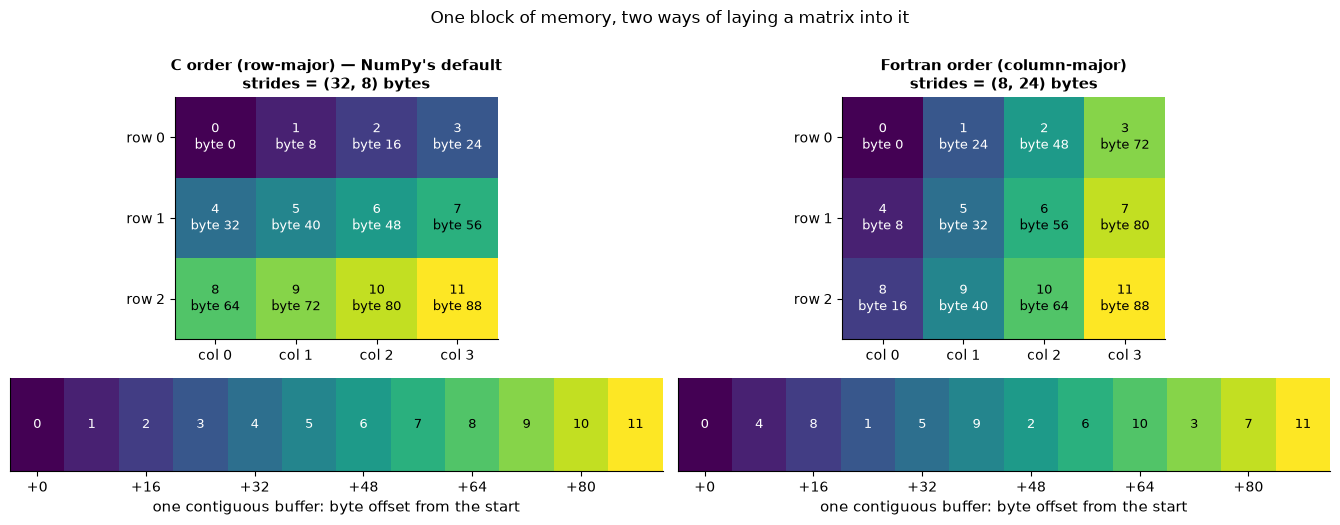

A.T is a view with swapped strides: (32, 8) -> (8, 32) | shares memory: True


In [48]:
A = np.arange(12, dtype=np.float64).reshape(3, 4)
# offsets_*[i, j] is the position of element A[i, j] in memory, counted in elements
offsets_c = np.arange(12).reshape(3, 4)              # C order: last index varies fastest
offsets_f = np.arange(12).reshape(4, 3).T            # Fortran order: first index varies fastest

# 2 x 2 grid of panels: top row shows the matrix, bottom row the flat memory buffer (height_ratios makes the top taller)
fig, axes = plt.subplots(2, 2, figsize=(13.5, 5.2), gridspec_kw={"height_ratios": [2.6, 1]})
for col, (offsets, name, arr_ord) in enumerate([(offsets_c, "C order (row-major) — NumPy's default", "C"),
                                                (offsets_f, "Fortran order (column-major)", "F")]):
    # --- top: the 3 x 4 matrix, each cell coloured by where it lives in memory
    ax = axes[0, col]
    ax.imshow(offsets, cmap="viridis", vmin=0, vmax=11)     # imshow draws a 2-D array as a grid of coloured cells
    for i in range(3):
        for j in range(4):
            # label each cell with its value and its byte offset (8 bytes per float64), white text on dark cells
            ax.text(j, i, f"{A[i, j]:.0f}\nbyte {8 * offsets[i, j]}", ha="center", va="center", fontsize=9,
                    color="white" if offsets[i, j] < 7 else "black")
    ax.set_xticks(range(4), [f"col {j}" for j in range(4)])     # tick positions and their labels
    ax.set_yticks(range(3), [f"row {i}" for i in range(3)])
    # np.asarray(A, order=...) returns A in the requested memory order, so we can read that order's strides
    ax.set_title(f"{name}\nstrides = {np.asarray(A, order=arr_ord).strides} bytes", fontsize=11)
    ax.grid(False)

    # --- bottom: the same 12 values in the order they sit in memory
    buf = axes[1, col]
    order_vals = A.ravel(order=arr_ord)                     # flatten to 1-D, reading in C or Fortran order
    buf.imshow(np.arange(12)[None, :], cmap="viridis", vmin=0, vmax=11, aspect="auto")   # a 1 x 12 colour strip
    for k, v in enumerate(order_vals):
        buf.text(k, 0, f"{v:.0f}", ha="center", va="center", fontsize=9,
                 color="white" if k < 7 else "black")
    buf.set_yticks([])
    buf.set_xticks(range(0, 12, 2), [f"+{8 * k}" for k in range(0, 12, 2)])   # label every second byte offset
    buf.set_xlabel("one contiguous buffer: byte offset from the start")
    buf.grid(False)
fig.suptitle("One block of memory, two ways of laying a matrix into it", y=1.0)   # one title above all panels
plt.tight_layout()
plt.show()
print("A.T is a view with swapped strides:", A.strides, "->", A.T.strides,
      "| shares memory:", np.shares_memory(A, A.T))

## 2. Arrays: creation, shapes, indexing, views and reductions

### 2.1 Creating arrays and reshaping

In [49]:
zeros = np.zeros((2, 3))                 # 2 x 3 array filled with 0.0; the shape is a tuple
ones = np.ones(4)                        # filled with 1.0; a single int gives a 1-D array
ident = np.eye(3)                        # identity matrix: 1 on the diagonal, 0 elsewhere
grid = np.linspace(0, 1, 5)              # 5 evenly spaced points including both ends
seq = np.arange(0, 10, 2)                # like range(): start, stop (exclusive), step
noise = rng.normal(loc=0, scale=1, size=(2, 3))   # random arrays come from the generator (section 5)

v = np.arange(6)                         # [0 1 2 3 4 5], shape (6,)
# .reshape(...) gives the same data a new shape; the total number of elements must stay the same
print("v          ", v, v.shape)
print("v.reshape  ", v.reshape(2, 3).shape, "| -1 infers the remaining size:", v.reshape(-1, 2).shape)
print("column vec ", v[:, None].shape, "| row vec", v[None, :].shape, "  (None inserts an axis of length 1)")
print("ravel      ", v.reshape(2, 3).ravel().shape, "(back to 1-D; a view when possible, .flatten() always copies)")

v           [0 1 2 3 4 5] (6,)
v.reshape   (2, 3) | -1 infers the remaining size: (3, 2)
column vec  (6, 1) | row vec (1, 6)   (None inserts an axis of length 1)
ravel       (6,) (back to 1-D; a view when possible, .flatten() always copies)


Two shape conventions matter for the whole course. A **feature matrix** `X` is always 2-D
with shape `(n_samples, n_features)`, even if there is only one feature — that is why the
exemplar notebooks write `x[:, None]` before passing a 1-D array to scikit-learn. A
**target vector** `y` is 1-D with shape `(n_samples,)`. Confusing `(n,)` with `(n, 1)` is
the most common shape bug; the broadcasting section shows how it can silently produce an
`(n, n)` matrix.

### 2.2 Indexing: slices, boolean masks, fancy indexing

NumPy offers three kinds of indexing, and they differ in an important way: **basic slicing
returns a view** (a window onto the same memory), whereas **boolean and integer-array
("fancy") indexing return copies**.

In [50]:
X = np.arange(20).reshape(4, 5)          # the numbers 0..19 as a 4 x 5 matrix
print(X)
# basic indexing: X[row, column]; ":" means "everything along this axis", "start:stop:step" is a slice
print("X[1, 2]     ->", X[1, 2], "      (row 1, column 2 — zero-based)")
print("X[1]        ->", X[1], "      (whole row 1)")
print("X[:, 2]     ->", X[:, 2], "     (whole column 2)")
print("X[1:3, ::2] ->\n", X[1:3, ::2], "   (rows 1-2, every second column)")
print("X[-1, -2:]  ->", X[-1, -2:], "        (negative indices count from the end)")

mask = X[:, 0] > 5                      # boolean mask over rows: the comparison gives one True/False per row
print("rows whose first entry > 5:\n", X[mask])          # indexing with a mask keeps the rows where it is True
print("X[X % 7 == 0] ->", X[X % 7 == 0], "(element-wise mask flattens the result)")   # % is the remainder
print("fancy: rows [3, 0], all columns ->\n", X[[3, 0]])  # "fancy" indexing: a list of positions, in that order
# np.where(cond, a, b) takes a where cond is True and b where it is False, element by element
print("np.where(cond, a, b) ->", np.where(X[0] > 2, "big", "small"))
# argmax: position of the largest value | argsort: the positions that would sort the array
print("argmax / argsort ->", X[0].argmax(), np.argsort([30, 10, 20]))

[[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]
 [15 16 17 18 19]]
X[1, 2]     -> 7       (row 1, column 2 — zero-based)
X[1]        -> [5 6 7 8 9]       (whole row 1)
X[:, 2]     -> [ 2  7 12 17]      (whole column 2)
X[1:3, ::2] ->
 [[ 5  7  9]
 [10 12 14]]    (rows 1-2, every second column)
X[-1, -2:]  -> [18 19]         (negative indices count from the end)
rows whose first entry > 5:
 [[10 11 12 13 14]
 [15 16 17 18 19]]
X[X % 7 == 0] -> [ 0  7 14] (element-wise mask flattens the result)
fancy: rows [3, 0], all columns ->
 [[15 16 17 18 19]
 [ 0  1  2  3  4]]
np.where(cond, a, b) -> ['small' 'small' 'small' 'big' 'big']
argmax / argsort -> 4 [1 2 0]


### 2.3 Views versus copies

A view shares memory with its parent: writing to it writes to the parent. This is a feature
(slicing a huge array costs nothing) and a trap (modifying a "sub-array" changes the
original). When in doubt, ask `np.shares_memory` or call `.copy()`.

In [51]:
a = np.arange(10)       # [0 1 2 ... 9]
b = a[2:5]              # basic slice -> view (b looks at elements 2, 3, 4 of a's buffer)
b[:] = -1               # writes through to a (b[:] = ... assigns into every element in place)
c = a[[7, 8]]           # fancy index -> copy
c[:] = 99               # a is unaffected
print("a after modifying the slice b and the copy c:", a)
print("b shares memory with a:", np.shares_memory(a, b), "| c shares memory with a:", np.shares_memory(a, c))
d = a[2:5].copy()       # explicit copy when you need independence
# reshape returns a view of the same buffer, while arithmetic such as a + 0 always allocates a new array
print("reshape is a view:", np.shares_memory(a, a.reshape(2, 5)), "| a + 0 is a new array:", np.shares_memory(a, a + 0))

a after modifying the slice b and the copy c: [ 0  1 -1 -1 -1  5  6  7  8  9]
b shares memory with a: True | c shares memory with a: False
reshape is a view: True | a + 0 is a new array: False


The difference is a statement about *memory*, so let us draw the memory. In the left panel
the three cells of `b` are the very same cells of `a`, which is why writing `-1` into `b`
changes `a`. In the right panel `c` has its own two cells, filled with copies of the values,
so writing `99` into it leaves `a` alone.

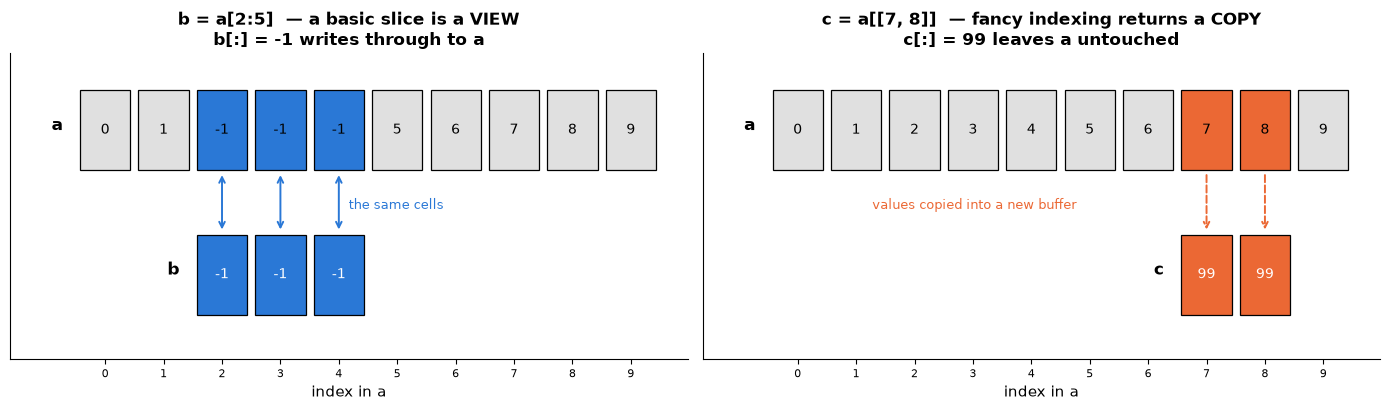

In [52]:
def cell_row(ax, values, y, colours, x0=0.0, width=0.86, height=0.72, fontsize=10, text_colour="black"):
    """Draw a row of labelled boxes starting at x0 — a picture of a 1-D array.

    ax          the matplotlib axes to draw on
    values      the numbers to write in the boxes, one box per value
    y           vertical position of the bottom edge of the row
    colours     one fill colour per box
    x0          horizontal position of the first box; box i starts at x0 + i
    width, height, fontsize, text_colour   size of each box and look of its label
    """
    for i, v in enumerate(values):
        # plt.Rectangle((x, y), w, h) is a box whose lower-left corner is (x, y); add_patch draws it on ax
        ax.add_patch(plt.Rectangle((x0 + i, y), width, height, facecolor=colours[i],
                                   edgecolor="black", lw=0.9))
        # write the value in the centre of the box
        ax.text(x0 + i + width / 2, y + height / 2, f"{v}", ha="center", va="center",
                fontsize=fontsize, color=text_colour)

a_after = np.arange(10)
a_after[2:5] = -1                                   # the state of `a` after writing through the view
grey, blue, orange = "0.88", PALETTE[0], PALETTE[1]  # a number in a string is a grey level (0 = black, 1 = white)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
# --- left: basic slice -> view
cell_row(axes[0], a_after, 1.3, [blue if 2 <= i < 5 else grey for i in range(10)])   # top row: a, slice highlighted
cell_row(axes[0], a_after[2:5], 0.0, [blue] * 3, x0=2.0, text_colour="white")       # bottom row: b, under its cells
for k in range(3):
    # annotate("", xy=..., xytext=..., arrowprops=...) draws only an arrow, from xytext to xy
    axes[0].annotate("", xy=(2 + k + 0.43, 1.28), xytext=(2 + k + 0.43, 0.74),
                     arrowprops={"arrowstyle": "<->", "lw": 1.4, "color": PALETTE[0]})
axes[0].text(4.6, 0.95, "the same cells", ha="left", fontsize=9, color=PALETTE[0])
axes[0].set_title("b = a[2:5]  — a basic slice is a VIEW\nb[:] = -1 writes through to a")
axes[0].text(-0.3, 1.66, "a", fontsize=12, fontweight="bold", ha="right")
axes[0].text(1.7, 0.36, "b", fontsize=12, fontweight="bold", ha="right")

# --- right: fancy index -> copy
cell_row(axes[1], np.arange(10), 1.3, [orange if i in (7, 8) else grey for i in range(10)])
cell_row(axes[1], [99, 99], 0.0, [orange] * 2, x0=7.0, text_colour="white")
for k in range(2):
    axes[1].annotate("", xy=(7 + k + 0.43, 0.74), xytext=(7 + k + 0.43, 1.28),
                     arrowprops={"arrowstyle": "->", "lw": 1.4, "ls": "--", "color": PALETTE[1]})
axes[1].text(5.2, 0.95, "values copied into a new buffer", ha="right", fontsize=9, color=PALETTE[1])
axes[1].set_title("c = a[[7, 8]]  — fancy indexing returns a COPY\nc[:] = 99 leaves a untouched")
axes[1].text(-0.3, 1.66, "a", fontsize=12, fontweight="bold", ha="right")
axes[1].text(6.7, 0.36, "c", fontsize=12, fontweight="bold", ha="right")

for ax in axes:
    ax.set_xlim(-1.2, 10.4)                 # fixed coordinate ranges so both panels line up
    ax.set_ylim(-0.4, 2.35)
    ax.set_xticks(np.arange(10) + 0.43, [str(i) for i in range(10)], fontsize=8)   # index labels under box centres
    ax.set_yticks([])
    ax.set_xlabel("index in a")
    ax.grid(False)
plt.tight_layout()
plt.show()

### 2.4 Reductions and the meaning of `axis`

`sum`, `mean`, `std`, `min`, `max`, `argmax`, `any`, `all` and friends *reduce* an array. With
no `axis` they reduce everything to a scalar. With `axis=k` they **collapse axis $k$**: the
result has the same shape as the input with axis $k$ removed. For a feature matrix of shape
`(n, d)`, `axis=0` runs down the rows and produces one number per column (a per-feature
statistic, shape `(d,)`), and `axis=1` runs across the columns and produces one number per
row (shape `(n,)`). The mnemonic: *the axis you name is the one that disappears.*

In [53]:
X = rng.normal(size=(6, 3))       # 6 samples (rows) x 3 features (columns) of standard-normal random numbers
print("X.shape           ", X.shape)
# with no axis, .mean() averages every element; np.round(x, 3) / x.round(3) round to 3 decimals
print("X.mean()          ", np.round(X.mean(), 3), "        (everything)")
print("X.mean(axis=0)    ", X.mean(axis=0).round(3), "  shape", X.mean(axis=0).shape, "<- one value per column (feature)")
print("X.mean(axis=1)    ", X.mean(axis=1).round(3), "  shape", X.mean(axis=1).shape, "<- one value per row (sample)")
print("keepdims=True     ", X.mean(axis=0, keepdims=True).shape, "(keeps a length-1 axis, handy for broadcasting)")
print("argmax per row    ", X.argmax(axis=1), "(index of the largest column in each row)")

X.shape            (6, 3)
X.mean()           0.102         (everything)
X.mean(axis=0)     [-0.22   0.539 -0.012]   shape (3,) <- one value per column (feature)
X.mean(axis=1)     [-0.068  0.268  0.554 -0.483  0.215  0.129]   shape (6,) <- one value per row (sample)
keepdims=True      (1, 3) (keeps a length-1 axis, handy for broadcasting)
argmax per row     [0 1 1 1 0 1] (index of the largest column in each row)


If the mnemonic still feels slippery, keep this picture in mind. The same 4 × 3 matrix is
reduced twice: naming `axis=0` collapses the *rows* and leaves one number per column;
naming `axis=1` collapses the *columns* and leaves one number per row. The arrows point along
the axis that disappears.

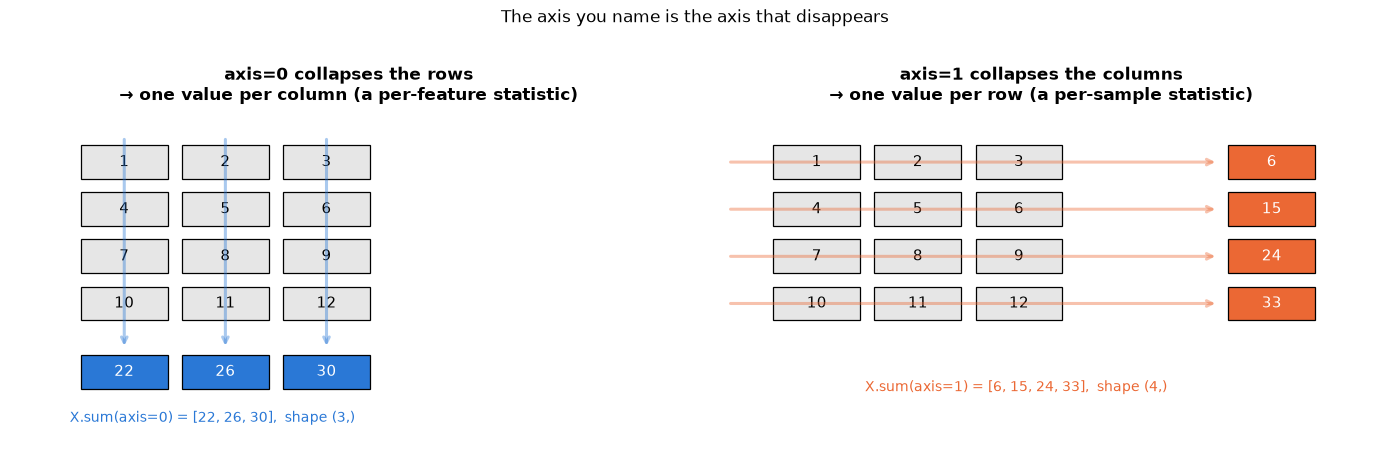

In [54]:
M = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9], [10, 11, 12]])
grey, blue, orange = "0.9", PALETTE[0], PALETTE[1]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))
for ax in axes:                                   # the same 4 x 3 matrix in both panels
    for i in range(4):
        cell_row(ax, M[i], y=3.0 - i, colours=[grey] * 3, fontsize=11)   # one row of boxes per matrix row
    ax.set_xlim(-0.7, 6.0)
    ax.set_ylim(-2.6, 4.5)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)
    for spine in ax.spines.values():        # a diagram needs no axes frame
        spine.set_visible(False)

# --- left: summing down the columns
col_sums = M.sum(axis=0)                          # axis 0 disappears: one value per column
cell_row(axes[0], col_sums, y=-1.45, colours=[blue] * 3, text_colour="white", fontsize=11)
for j in range(3):
    # one downward arrow per column, from the top of the matrix to its sum
    axes[0].annotate("", xy=(j + 0.43, -0.6), xytext=(j + 0.43, 3.9),
                     arrowprops={"arrowstyle": "->", "lw": 2.2, "color": blue, "alpha": 0.4})
# .tolist() converts the array to a plain Python list for a cleaner label
axes[0].text(1.3, -2.15, f"X.sum(axis=0) = {col_sums.tolist()},  shape {col_sums.shape}",
             ha="center", fontsize=10, color=blue)
axes[0].set_title("axis=0 collapses the rows\n→ one value per column (a per-feature statistic)")

# --- right: summing along the rows
row_sums = M.sum(axis=1)                          # axis 1 disappears: one value per row
for i, v in enumerate(row_sums):
    cell_row(axes[1], [v], y=3.0 - i, colours=[orange], x0=4.5, text_colour="white", fontsize=11)
    # one rightward arrow per row, from the row to its sum
    axes[1].annotate("", xy=(4.4, 3.36 - i), xytext=(-0.45, 3.36 - i),
                     arrowprops={"arrowstyle": "->", "lw": 2.2, "color": orange, "alpha": 0.4})
axes[1].text(2.4, -1.5, f"X.sum(axis=1) = {row_sums.tolist()},  shape {row_sums.shape}",
             ha="center", fontsize=10, color=orange)
axes[1].set_title("axis=1 collapses the columns\n→ one value per row (a per-sample statistic)")
fig.suptitle("The axis you name is the axis that disappears", y=1.02)
plt.tight_layout()
plt.show()

## 3. Broadcasting

Broadcasting is the rule by which NumPy combines arrays of *different* shapes without
copying data. It is the key to writing loop-free code, and once it clicks, most numerical
code becomes short and obvious. The rule (NumPy documentation, *Broadcasting*):

> **Broadcasting rule.** Compare the shapes of the two operands **from the right** (the
> trailing dimensions). Two dimensions are compatible if they are *equal* or if *one of them
> is 1*. A missing dimension counts as 1. The result has, in each position, the larger of
> the two sizes, and every length-1 dimension is "stretched" (virtually, with no memory
> cost) to match.

So `(n, d)` and `(d,)` are compatible: `(d,)` is padded to `(1, d)` and stretched to
`(n, d)`. `(n, d)` and `(n,)` are **not** compatible — `(n,)` is padded to `(1, n)`, and
`n ≠ d`. To subtract a per-row quantity you must give it shape `(n, 1)` with `[:, None]`.

**Example 1 — standardising columns.** Subtract each column's mean and divide by its
standard deviation. `X.mean(axis=0)` has shape `(d,)`, which broadcasts against `(n, d)`.

**Example 2 — an outer product / a 2-D grid from two 1-D arrays.** Give one array shape
`(n, 1)` and the other `(1, m)`; the result is `(n, m)`.

In [55]:
# Example 1: standardise columns
# rng.normal accepts one loc (mean) and one scale (standard deviation) per column
X = rng.normal(loc=[10, 200, -5], scale=[1, 50, 0.1], size=(1000, 3))   # three features on wildly different scales
# subtract each column's mean, then divide by each column's standard deviation
X_std = (X - X.mean(axis=0)) / X.std(axis=0)         # (1000, 3) - (3,) -> (1000, 3)
# .round(10) hides floating-point noise such as 1e-17, so the results read as exactly 0 and 1
print("column means after standardising:", X_std.mean(axis=0).round(10))
print("column stds  after standardising:", X_std.std(axis=0).round(10))

# Example 2: outer product and pairwise differences
a = np.array([1, 2, 3])
b = np.array([10, 20, 30, 40])
table = a[:, None] * b[None, :]          # (3, 1) * (1, 4) -> (3, 4): table[i, j] = a[i] * b[j]
print("\nouter product a[:, None] * b[None, :]:\n", table)
print("a[:, None] - a[None, :] gives all pairwise differences:\n", a[:, None] - a[None, :])

column means after standardising: [ 0.  0. -0.]
column stds  after standardising: [1. 1. 1.]

outer product a[:, None] * b[None, :]:
 [[ 10  20  30  40]
 [ 20  40  60  80]
 [ 30  60  90 120]]
a[:, None] - a[None, :] gives all pairwise differences:
 [[ 0 -1 -2]
 [ 1  0 -1]
 [ 2  1  0]]


Example 2 is the whole rule in one picture. `a[:, None]` is a column of three numbers and
`b[None, :]` a row of four; NumPy pretends — without allocating anything — that the column
was repeated across four columns and the row down three rows, and then multiplies the two
`(3, 4)` grids element-wise. The **solid outline** marks the data that actually exist in
memory; the pale cells are the virtual copies.

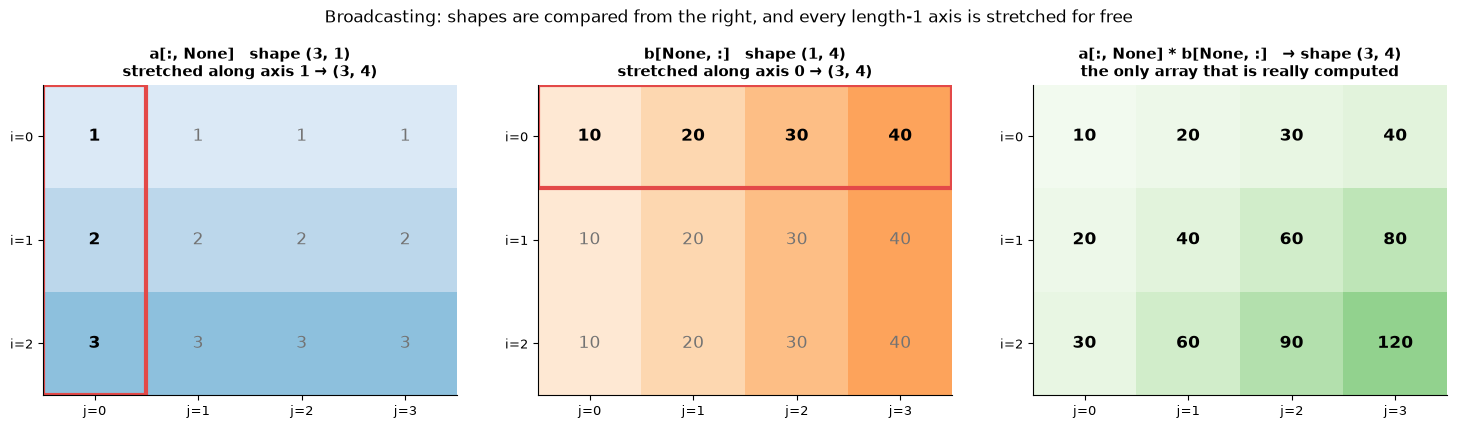

In [56]:
# np.broadcast_to(x, shape) returns a read-only view of x "stretched" to `shape` without copying data —
# exactly what broadcasting does behind the scenes. We only build these views here so we can draw them.
a_stretch = np.broadcast_to(a[:, None], (3, 4))
b_stretch = np.broadcast_to(b[None, :], (3, 4))
# each panel: (values to show, title, colour map, where the original data sits as (row, col, width, height) or None)
panels = [(a_stretch, "a[:, None]   shape (3, 1)\nstretched along axis 1 → (3, 4)", "Blues", (0, 0, 1, 3)),
          (b_stretch, "b[None, :]   shape (1, 4)\nstretched along axis 0 → (3, 4)", "Oranges", (0, 0, 4, 1)),
          (table, "a[:, None] * b[None, :]   → shape (3, 4)\nthe only array that is really computed", "Greens", None)]

fig, axes = plt.subplots(1, 3, figsize=(15, 3.9))
for ax, (values, title, cmap, real) in zip(axes, panels):    # zip pairs each axes with its panel description
    ax.imshow(values, cmap=cmap, vmin=0, vmax=values.max() * 2.4)   # stay in the light half: text must stay legible
    for i in range(3):
        for j in range(4):
            # is cell (i, j) part of the original data? bold black if so, grey if it is only a broadcast copy
            is_real = real is None or (real[0] <= i < real[0] + real[3] and real[1] <= j < real[1] + real[2])
            ax.text(j, i, f"{values[i, j]}", ha="center", va="center", fontsize=12,
                    color="black" if is_real else "0.45",
                    fontweight="bold" if is_real else "normal")
    if real is not None:
        # outline the original data; the -0.5 is because imshow centres cell (i, j) on integer coordinates
        ax.add_patch(plt.Rectangle((real[1] - 0.5, real[0] - 0.5), real[2], real[3],
                                   fill=False, edgecolor=PALETTE[7], lw=3))
    ax.set_xticks(range(4), [f"j={j}" for j in range(4)], fontsize=9)
    ax.set_yticks(range(3), [f"i={i}" for i in range(3)], fontsize=9)
    ax.set_title(title, fontsize=10.5)
    ax.grid(False)
fig.suptitle("Broadcasting: shapes are compared from the right, and every length-1 axis is stretched for free",
             y=1.03)
plt.tight_layout()
plt.show()

**Example 3 — a pairwise distance matrix without loops.** For $\mathbf{X} \in \mathbb{R}^{n
\times d}$ and $\mathbf{Y} \in \mathbb{R}^{m \times d}$ we want
$D_{ij} = \|\mathbf{x}_i - \mathbf{y}_j\|_2$. Insert axes so that the shapes are
`(n, 1, d)` and `(1, m, d)`; the difference is `(n, m, d)`; square, sum over the last axis,
take the root. This is exactly the computation inside $k$-nearest neighbours (notebook 8)
and $k$-means (notebook 13).

In [57]:
from scipy.spatial.distance import cdist     # SciPy's optimised pairwise-distance function

X = rng.normal(size=(500, 5))    # 500 points in 5 dimensions
Y = rng.normal(size=(300, 5))    # 300 more points in the same 5 dimensions

def pairwise_loops(X, Y):
    """Euclidean distance from every row of X to every row of Y, one pair at a time (slow baseline).

    Returns D of shape (len(X), len(Y)) with D[i, j] = ||X[i] - Y[j]||.
    """
    D = np.empty((len(X), len(Y)))     # allocate the result without filling it (every entry is overwritten below)
    for i in range(len(X)):
        for j in range(len(Y)):
            D[i, j] = np.sqrt(np.sum((X[i] - Y[j]) ** 2))   # square root of the sum of squared differences
    return D

def pairwise_broadcast(X, Y):
    """The same distance matrix, computing all n * m differences at once with broadcasting."""
    diff = X[:, None, :] - Y[None, :, :]            # (n, 1, d) - (1, m, d) -> (n, m, d)
    return np.sqrt((diff ** 2).sum(axis=-1))        # -> (n, m)   (axis=-1 means the last axis, d)

def pairwise_identity(X, Y):
    """The same distance matrix from an algebraic identity: the fastest pure-NumPy version."""
    # ||x - y||^2 = ||x||^2 + ||y||^2 - 2 x.y : no (n, m, d) intermediate, one matrix product
    sq = (X ** 2).sum(axis=1)[:, None] + (Y ** 2).sum(axis=1)[None, :] - 2 * X @ Y.T
    return np.sqrt(np.maximum(sq, 0))               # clip tiny negative round-off before the sqrt

D_loop, D_bc, D_id, D_scipy = pairwise_loops(X, Y), pairwise_broadcast(X, Y), pairwise_identity(X, Y), cdist(X, Y)
# np.allclose(a, b) is True when every entry matches up to a tiny floating-point tolerance
print("all four agree:", np.allclose(D_loop, D_bc) and np.allclose(D_bc, D_id) and np.allclose(D_id, D_scipy))

# time each method (the double loop is so slow that 2 repeats are enough)
dist_times = {
    "double Python loop": time_ms(lambda: pairwise_loops(X, Y), repeats=2),
    "broadcasting\n(n, m, d) intermediate": time_ms(lambda: pairwise_broadcast(X, Y)),
    "algebraic identity\n(one matrix product)": time_ms(lambda: pairwise_identity(X, Y)),
    "scipy.spatial.distance.cdist": time_ms(lambda: cdist(X, Y)),
}
for name, t in dist_times.items():
    # chr(10) is "\n": swap the line breaks meant for the plot labels for spaces; :38s pads the name to 38 characters
    print(f"{name.replace(chr(10), ' '):38s} {t:8.1f} ms")
# n * m * d numbers at 8 bytes each, converted to MB
print(f"the broadcast version allocates an (n, m, d) = "
      f"{X.shape[0] * Y.shape[0] * X.shape[1] * 8 / 1e6:.1f} MB intermediate; the other three do not")

all four agree: True
double Python loop                        410.2 ms
broadcasting (n, m, d) intermediate         4.7 ms
algebraic identity (one matrix product)      0.4 ms
scipy.spatial.distance.cdist                0.4 ms
the broadcast version allocates an (n, m, d) = 6.0 MB intermediate; the other three do not


The object we just built is worth looking at. The left panel shows the top-left 60 × 60
corner of $\mathbf{D}$ as a heat-map — one pixel per pair of points, bright where the two
points are far apart — which is exactly the matrix that $k$-nearest neighbours scans for its
smallest entries in each row. The right panel puts the four implementations on a log axis.

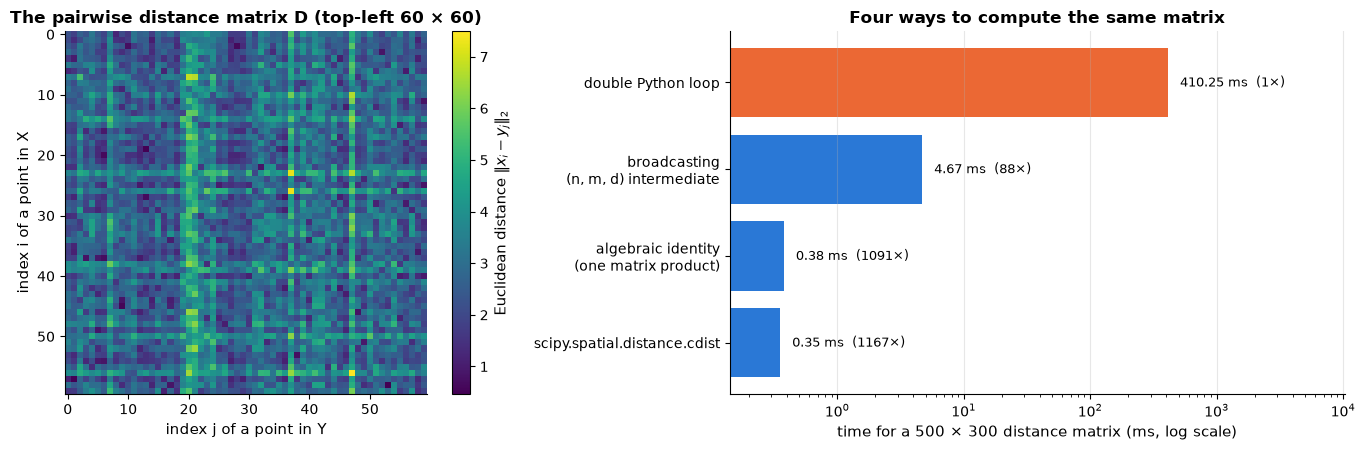

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), gridspec_kw={"width_ratios": [1, 1.25]})   # right panel 25 % wider
im = axes[0].imshow(D_bc[:60, :60], cmap="viridis")    # only the top-left 60 x 60 block, so single cells stay visible
fig.colorbar(im, ax=axes[0], label="Euclidean distance $\\|x_i - y_j\\|_2$")   # the colour scale next to the image
axes[0].set_xlabel("index j of a point in Y")
axes[0].set_ylabel("index i of a point in X")
axes[0].set_title("The pairwise distance matrix D (top-left 60 × 60)")
axes[0].grid(False)

methods, timings = list(dist_times), list(dist_times.values())    # list(dict) gives the keys in insertion order
axes[1].barh(methods, timings, color=[PALETTE[1]] + [PALETTE[0]] * 3)
for i, t in enumerate(timings):
    # each label shows the time and the speed-up relative to the double loop (timings[0])
    axes[1].text(t * 1.25, i, f"{t:.2f} ms  ({timings[0] / t:.0f}×)", va="center", fontsize=9)
axes[1].set_xscale("log")
axes[1].set_xlim(min(timings) * 0.4, max(timings) * 25)
axes[1].invert_yaxis()
axes[1].set_xlabel(f"time for a {X.shape[0]} × {Y.shape[0]} distance matrix (ms, log scale)")
axes[1].set_title("Four ways to compute the same matrix")
axes[1].grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

The broadcast version is roughly two orders of magnitude faster than the loops. The
"identity" version turns the whole computation into one matrix product, which is how
libraries do it: for these small arrays it is not necessarily faster than broadcasting, but
it needs no `(n, m, d)` temporary — and that temporary is the price of broadcasting: it
would be 8 GB for $n = m = 10^4$, $d = 10$. When a broadcast intermediate gets large, look
for an algebraic identity or a library routine.

> **Warning — the `(n,)` versus `(n, 1)` trap.** Subtracting a `(n,)` array from a `(n, 1)`
> array does not raise an error: it broadcasts to `(n, n)`. A prediction vector of shape
> `(n, 1)` (as returned by some models) minus a target of shape `(n,)` gives an `(n, n)`
> residual matrix whose mean is *not* the mean residual. Always check `.shape`, and `ravel()`
> predictions before computing errors.

In [59]:
y_true = np.array([1.0, 2.0, 3.0])                # shape (3,)
y_pred = np.array([[1.1], [2.1], [2.9]])          # shape (3, 1) — a common output shape
# (3, 1) - (3,) broadcasts to (3, 3): every prediction minus every target
print("y_pred - y_true has shape", (y_pred - y_true).shape, "<- silently wrong")
# .ravel() flattens (3, 1) to (3,), so prediction i is paired with target i
print("y_pred.ravel() - y_true has shape", (y_pred.ravel() - y_true).shape, "<- what we meant")

y_pred - y_true has shape (3, 3) <- silently wrong
y_pred.ravel() - y_true has shape (3,) <- what we meant


## 4. Linear algebra in NumPy

Linear algebra is the language of half this course: least squares (notebook 6), PCA and the
SVD (notebook 14), the forward pass of a neural network. Notebook 2 explains
the mathematics; here is the toolbox.

| Operation | NumPy | Notes |
|---|---|---|
| matrix product | `A @ B`, `A.T @ b` | `*` is *element-wise*, never a matrix product |
| solve $\mathbf{A}\mathbf{x} = \mathbf{b}$ | `np.linalg.solve(A, b)` | square, invertible $\mathbf{A}$; never form the inverse |
| least squares $\min_{\mathbf{w}} \|\mathbf{X}\mathbf{w}-\mathbf{y}\|_2$ | `np.linalg.lstsq(X, y, rcond=None)` | rectangular $\mathbf{X}$; via SVD, numerically robust |
| norms | `np.linalg.norm(v)`, `norm(v, 1)`, `norm(A, "fro")` | Euclidean, Manhattan, Frobenius |
| SVD | `U, s, Vt = np.linalg.svd(A, full_matrices=False)` | `s` sorted descending |
| eigen-decomposition | `np.linalg.eigh(S)` (symmetric), `np.linalg.eig(A)` (general) | `eigh` is faster and returns real, sorted eigenvalues |
| inverse, determinant, rank, condition number | `inv`, `det`, `matrix_rank`, `cond` | diagnostics; `inv` mostly for tiny matrices in derivations |

### 4.1 `solve` versus `inv`

Textbooks write $\mathbf{x} = \mathbf{A}^{-1}\mathbf{b}$; code should never compute it that
way. `np.linalg.solve` factorises $\mathbf{A}$ (an LU decomposition, about $\tfrac{2}{3}n^3$
floating-point operations) and then solves two triangular systems; forming the inverse
costs roughly three times as much *and* is less accurate when $\mathbf{A}$ is
ill-conditioned. The **condition number** `np.linalg.cond(A)` measures how much relative
error in the input can be amplified in the output; as a rule of thumb you lose
$\log_{10}(\text{cond})$ significant digits. The Hilbert matrix $H_{ij} = 1/(i+j-1)$ is a
classic ill-conditioned example: with a condition number around $10^{13}$ we can hope for
about three correct digits, and the inverse does markedly worse than `solve`.

In [60]:
from scipy.linalg import hilbert     # hilbert(n) builds the n x n matrix with H[i, j] = 1 / (i + j + 1)

H = hilbert(10)
x_true = np.ones(10)          # the solution we want to recover
b = H @ x_true                # @ is matrix multiplication: a right-hand side whose exact solution is x_true
# np.linalg.cond: the condition number, i.e. how much errors in b can be amplified in the solution
print(f"condition number of the 10x10 Hilbert matrix: {np.linalg.cond(H):.1e}")
# solve H x = b three ways and report the largest error of each:
#   np.linalg.solve(H, b)   LU factorisation, the standard way to solve a square system
#   np.linalg.inv(H) @ b    builds the explicit inverse first, then multiplies (less accurate, avoid it)
#   np.linalg.lstsq(H, b)   SVD-based least-squares solver; [0] picks the solution from the tuple it returns
for name, x_hat in [("solve", np.linalg.solve(H, b)), ("inv(H) @ b", np.linalg.inv(H) @ b),
                    ("lstsq", np.linalg.lstsq(H, b, rcond=None)[0])]:
    # :11s pads the name to 11 characters; :.2e prints in scientific notation with 2 decimals
    print(f"  {name:11s} max |x_hat - x_true| = {np.abs(x_hat - x_true).max():.2e}")

condition number of the 10x10 Hilbert matrix: 1.6e+13
  solve       max |x_hat - x_true| = 1.69e-04
  inv(H) @ b  max |x_hat - x_true| = 5.55e-03
  lstsq       max |x_hat - x_true| = 2.57e-04


Sweeping the size of the Hilbert matrix turns the rule of thumb into a picture. The
condition number grows roughly geometrically with $n$ (left; beyond $n \approx 13$ the matrix
is numerically singular and even `cond` stops being meaningful), and the achieved error grows
with it in lock-step (right). The dashed line is $\varepsilon_\text{machine} \times
\operatorname{cond}(\mathbf{H})$, the accuracy you should *expect*: forming the inverse sits
on or above it, `solve` is a little better, and `lstsq` — which discards the singular values
that carry only round-off — is the only one that stays well below it once the problem is
hopeless.

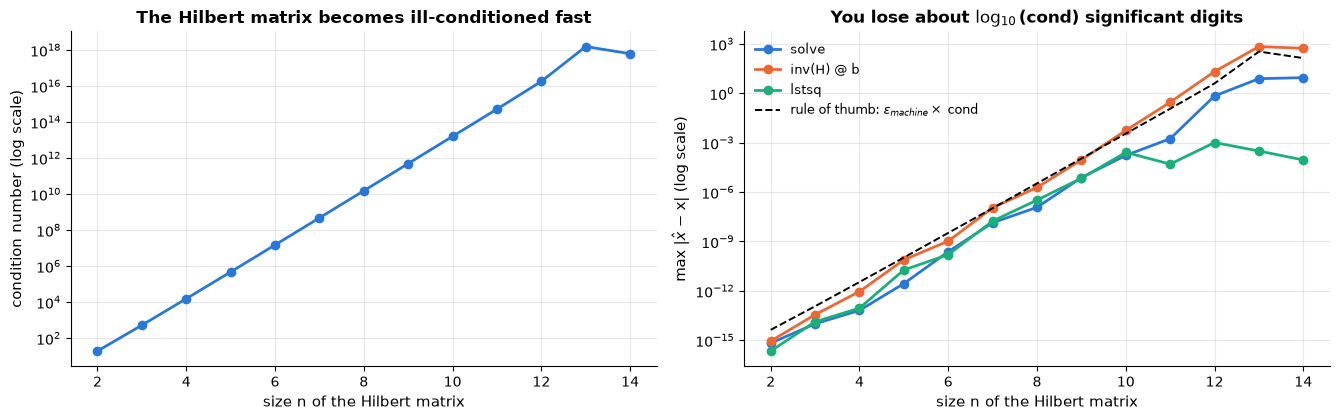

In [61]:
sizes = np.arange(2, 15)                                          # matrix sizes 2, 3, ..., 14
conds, errs = [], {"solve": [], "inv(H) @ b": [], "lstsq": []}    # condition numbers, and one error list per solver
for n_h in sizes:
    # the experiment of the previous cell, repeated for a Hilbert matrix of size n_h
    Hn = hilbert(n_h)
    xn = np.ones(n_h)
    bn = Hn @ xn
    conds.append(np.linalg.cond(Hn))
    errs["solve"].append(np.abs(np.linalg.solve(Hn, bn) - xn).max())
    errs["inv(H) @ b"].append(np.abs(np.linalg.inv(Hn) @ bn - xn).max())
    errs["lstsq"].append(np.abs(np.linalg.lstsq(Hn, bn, rcond=None)[0] - xn).max())

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.3))
axes[0].plot(sizes, conds, marker="o", color=PALETTE[0])     # a line with a dot at every data point
axes[0].set_yscale("log")
axes[0].set_xlabel("size n of the Hilbert matrix")
axes[0].set_ylabel("condition number (log scale)")
axes[0].set_title("The Hilbert matrix becomes ill-conditioned fast")

for (name, e), colour in zip(errs.items(), [PALETTE[0], PALETTE[1], PALETTE[2]]):
    # np.maximum(e, 1e-18) replaces an error of exactly 0 by a tiny value, because log(0) cannot be plotted
    axes[1].plot(sizes, np.maximum(e, 1e-18), marker="o", label=name, color=colour)
# np.finfo(float).eps (about 2.2e-16) is the gap between 1.0 and the next float64: the "machine epsilon"
axes[1].plot(sizes, np.finfo(float).eps * np.array(conds), ls="--", color="black", lw=1.4,
             label=r"rule of thumb: $\varepsilon_{machine}\times$ cond")
axes[1].set_yscale("log")
axes[1].set_xlabel("size n of the Hilbert matrix")
axes[1].set_ylabel("max |$\\hat{x}$ − x| (log scale)")
axes[1].set_title("You lose about $\\log_{10}$(cond) significant digits")
axes[1].legend(loc="upper left", fontsize=9)     # a box listing the label= of each line
plt.tight_layout()
plt.show()

### 4.2 A least-squares fit by hand (preview of notebook 6)

Given $n$ points $(x_i, y_i)$ we want the line $\hat{y} = w_0 + w_1 x$ that minimises the
sum of squared errors $\sum_i (y_i - w_0 - w_1 x_i)^2$. Stack the inputs into a **design
matrix** $\mathbf{X} \in \mathbb{R}^{n \times 2}$ whose first column is all ones (for the
intercept) and second column is $x$; then the problem is $\min_{\mathbf{w}}
\|\mathbf{X}\mathbf{w} - \mathbf{y}\|_2^2$, and its solution satisfies the **normal
equations** $\mathbf{X}^\top\mathbf{X}\,\mathbf{w} = \mathbf{X}^\top\mathbf{y}$ (derived in
notebook 2, section 2.3, and again in notebook 6). Three ways to compute it:

normal equations : [2.9257 2.0409]
lstsq            : [2.9257 2.0409]
LinearRegression : [2.9257 2.0409]


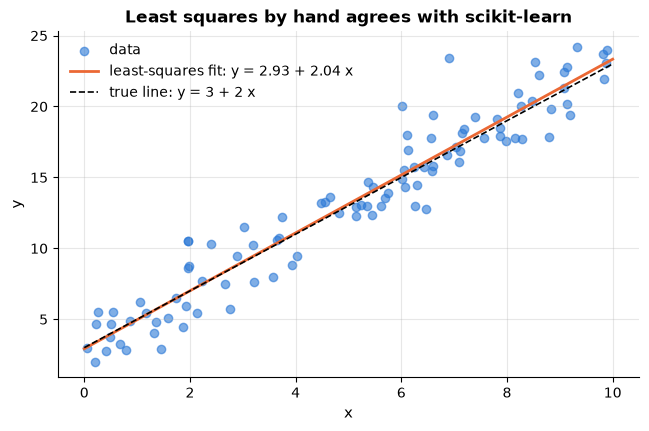

In [62]:
from sklearn.linear_model import LinearRegression

n = 100
x = rng.uniform(0, 10, n)                    # 100 x-values drawn uniformly from [0, 10)
y = 3 + 2 * x + rng.normal(0, 2, n)          # true intercept 3, true slope 2, plus noise with standard deviation 2

# np.column_stack puts 1-D arrays side by side as columns; the column of ones lets the first weight act as the intercept
X_design = np.column_stack([np.ones(n), x])   # shape (100, 2)
w_normal = np.linalg.solve(X_design.T @ X_design, X_design.T @ y)     # normal equations: solve (X^T X) w = X^T y
w_lstsq, *_ = np.linalg.lstsq(X_design, y, rcond=None)                 # SVD-based least squares (*_ discards the extras)
lr = LinearRegression().fit(x[:, None], y)                             # scikit-learn (fits its own intercept)
# note: scikit-learn expects X as a 2-D (n_samples, n_features) array, hence x[:, None]

print("normal equations :", w_normal.round(4))
print("lstsq            :", w_lstsq.round(4))
# attributes ending in "_" (intercept_, coef_) are the parameters that .fit() learned
print("LinearRegression :", np.array([lr.intercept_, lr.coef_[0]]).round(4))

fig, ax = plt.subplots()
ax.scatter(x, y, alpha=0.6, label="data")    # one dot per (x, y) pair; alpha makes the dots semi-transparent
x_grid = np.linspace(0, 10, 50)              # x positions at which the two lines are drawn
# the fitted line w0 + w1 * x, and the true line (dashed) for comparison
ax.plot(x_grid, w_lstsq[0] + w_lstsq[1] * x_grid, color=PALETTE[1], label=f"least-squares fit: y = {w_lstsq[0]:.2f} + {w_lstsq[1]:.2f} x")
ax.plot(x_grid, 3 + 2 * x_grid, color="black", ls="--", lw=1.2, label="true line: y = 3 + 2 x")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Least squares by hand agrees with scikit-learn")
ax.legend()
plt.show()

`lstsq` is the tool to prefer in practice: it handles rank-deficient $\mathbf{X}$ and
is numerically stable, whereas the normal equations square the condition number.

### 4.3 Norms, SVD and eigen-decomposition

In [63]:
v = np.array([3.0, -4.0])
# np.linalg.norm(v, ord): default (2) is the Euclidean length, 1 the sum of absolute values, np.inf the largest absolute value
print(f"||v||_2 = {np.linalg.norm(v):.1f}   ||v||_1 = {np.linalg.norm(v, 1):.1f}   ||v||_inf = {np.linalg.norm(v, np.inf):.1f}")

M = rng.normal(size=(5, 3))
# singular value decomposition M = U @ diag(s) @ Vt; full_matrices=False returns the compact ("thin") version
U, s, Vt = np.linalg.svd(M, full_matrices=False)
# np.diag(s) turns the vector s into a diagonal matrix, so the product rebuilds M
print("SVD shapes: U", U.shape, " s", s.shape, " Vt", Vt.shape, "| reconstruction ok:", np.allclose(U @ np.diag(s) @ Vt, M))
# matrix_rank counts the singular values that are not (numerically) zero
print("singular values (descending):", s.round(3), "| rank:", np.linalg.matrix_rank(M))

S = M.T @ M                                   # symmetric positive semi-definite (a Gram matrix)
eigenvalues, eigenvectors = np.linalg.eigh(S)  # ascending order for eigh (eigh is the solver for symmetric matrices)
# s[::-1] reverses s, because svd sorts descending while eigh sorts ascending
print("eigenvalues of M^T M:", eigenvalues.round(3), "= squared singular values:", (s[::-1] ** 2).round(3))
# the Frobenius norm is the square root of the sum of all squared entries of a matrix
print("Frobenius norm of M:", np.linalg.norm(M, "fro").round(3), "= sqrt(sum of squared singular values):", np.sqrt((s ** 2).sum()).round(3))

||v||_2 = 5.0   ||v||_1 = 7.0   ||v||_inf = 4.0
SVD shapes: U (5, 3)  s (3,)  Vt (3, 3) | reconstruction ok: True
singular values (descending): [3.381 1.347 1.275] | rank: 3
eigenvalues of M^T M: [ 1.626  1.815 11.434] = squared singular values: [ 1.626  1.815 11.434]
Frobenius norm of M: 3.857 = sqrt(sum of squared singular values): 3.857


The identity "eigenvalues of $\mathbf{M}^\top\mathbf{M}$ = squared singular values of
$\mathbf{M}$" is the bridge between PCA via the covariance matrix and PCA via the SVD
(notebooks 2 and 14).

## 5. Random numbers done right

Machine learning is full of randomness: data splits, bootstrap samples, weight
initialisation, stochastic gradient descent, random forests. Two rules make it manageable.

1. **Seed everything.** A pseudo-random generator is a deterministic function of its
   *seed*; fixing the seed makes an experiment reproducible — you, your colleague and your
   future self obtain the same numbers, so a change in results is a change in code or data,
   not noise. Notebook 18 returns to reproducibility as an engineering discipline.
2. **Use the `Generator` API** (`np.random.default_rng(seed)`), not the legacy functions
   `np.random.seed`, `np.random.rand`, `np.random.randn`. The legacy API manipulates one hidden
   *global* state: any library call that draws a random number silently changes what *your*
   next call returns, and two seeded pieces of code interfere with each other. A `Generator`
   object is explicit local state that you pass around (which is why every helper in this
   course takes `rng` as an argument); it also uses a better algorithm (PCG64) and has a
   cleaner interface (`integers` instead of `randint`, `normal(loc, scale, size)`, and so on).

In [64]:
# np.random.default_rng(seed) creates an independent generator; the same seed always gives the same stream
rng_a = np.random.default_rng(123)
rng_b = np.random.default_rng(123)
rng_c = np.random.default_rng(124)
print("same seed  ->", rng_a.normal(size=3).round(3), rng_b.normal(size=3).round(3))
print("other seed ->", rng_c.normal(size=3).round(3))

# the most common Generator methods:
#   integers(low, high, size)       random integers, low inclusive and high exclusive
#   random(size)                    floats uniform on [0, 1)
#   normal(mean, std, size)         samples from a normal (Gaussian) distribution
#   choice(items, size, p=...)      picks from items, with the given probabilities p
#   permutation(n)                  the numbers 0..n-1 in random order
#   choice(n, size, replace=False)  `size` distinct integers from 0..n-1
print("integers in [0, 6)     :", rng.integers(0, 6, size=8))
print("uniform on [0, 1)      :", rng.random(3).round(3))
print("normal(mu=5, sigma=2)  :", rng.normal(5, 2, size=3).round(2))
print("weighted choice        :", rng.choice(["A", "B", "C"], size=8, p=[0.7, 0.2, 0.1]))
print("permutation of 0..7    :", rng.permutation(8), "  <- how a data set is shuffled before splitting")
print("5 rows without replacement:", rng.choice(100, size=5, replace=False))

same seed  -> [-0.989 -0.368  1.288] [-0.989 -0.368  1.288]
other seed -> [-0.301 -0.578 -1.111]
integers in [0, 6)     : [1 0 0 0 3 1 0 1]
uniform on [0, 1)      : [0.496 0.749 0.187]
normal(mu=5, sigma=2)  : [2.38 5.85 6.81]
weighted choice        : ['C' 'B' 'A' 'B' 'A' 'A' 'A' 'A']
permutation of 0..7    : [2 4 6 5 3 0 7 1]   <- how a data set is shuffled before splitting
5 rows without replacement: [98 79 73 83 70]


`rng.permutation(n)` gives a random ordering of row indices — the basis of shuffling and
of train/test splitting. `rng.choice(n, size=n, replace=True)` draws *with* replacement: a
**bootstrap resample**, the basis of bagging and random forests (notebook 10) and of the
bootstrap confidence intervals of notebook 2. A first taste: the sampling distribution of
a mean, estimated by resampling.

sample mean 9.56;  bootstrap 95% percentile interval [7.81, 11.31]  (true mean 10)


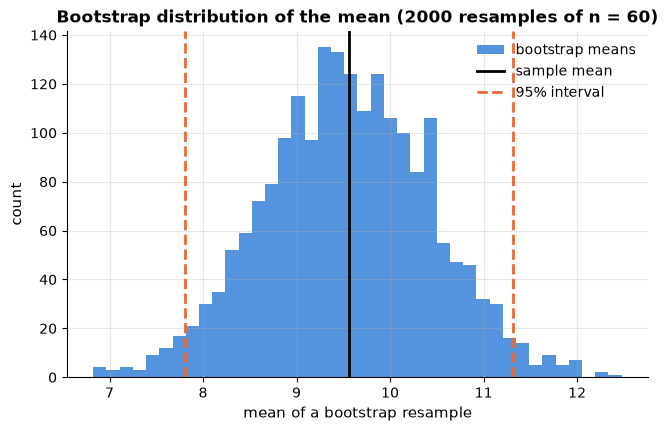

In [65]:
sample = rng.exponential(scale=10, size=60)          # a skewed sample of size 60 (true mean = 10)
n_boot = 2000                                        # number of bootstrap resamples
# one bootstrap resample = len(sample) values drawn *with replacement* from the sample; we keep the mean of each
boot_means = np.array([rng.choice(sample, size=len(sample), replace=True).mean() for _ in range(n_boot)])
lo, hi = np.percentile(boot_means, [2.5, 97.5])      # the bounds of the middle 95 % of the bootstrap means
print(f"sample mean {sample.mean():.2f};  bootstrap 95% percentile interval [{lo:.2f}, {hi:.2f}]  (true mean 10)")

fig, ax = plt.subplots()
ax.hist(boot_means, bins=40, color=PALETTE[0], alpha=0.8, label="bootstrap means")   # histogram with 40 bins
ax.axvline(sample.mean(), color="black", label="sample mean")      # axvline draws a vertical line at that x
ax.axvline(lo, color=PALETTE[1], ls="--", label="95% interval")
ax.axvline(hi, color=PALETTE[1], ls="--")
ax.set_xlabel("mean of a bootstrap resample")
ax.set_ylabel("count")
ax.set_title(f"Bootstrap distribution of the mean ({n_boot} resamples of n = {len(sample)})")
ax.legend()
plt.show()

## 6. pandas: tables with labels

NumPy arrays are homogeneous and anonymous: every element has the same type and rows and
columns are numbered. Real data are neither — a customer table mixes strings, dates,
integers and decimals, and its columns have names. pandas (McKinney, 2010; McKinney, 2022)
provides two objects for this:

- a **`Series`** — a 1-D array with a *name*, a *dtype* and an **index** (labels for the
  entries);
- a **`DataFrame`** — a dictionary of `Series` sharing one index: a table whose columns may
  have different dtypes.

The index is what distinguishes pandas from a spreadsheet or a NumPy array. Operations
between two Series **align on the index**, not on position:

In [66]:
# a Series is a 1-D array of values with an index (one label per value)
s1 = pd.Series([1, 2, 3], index=["a", "b", "c"])
s2 = pd.Series([10, 20, 30], index=["c", "b", "d"])
print("s1 + s2 aligns labels (a and d have no partner -> NaN):")
print(s1 + s2)        # values are matched by index label, not by position

s1 + s2 aligns labels (a and d have no partner -> NaN):
a     NaN
b    22.0
c    13.0
d     NaN
dtype: float64


Alignment is silent, which is convenient (joining on keys is automatic) and dangerous (a
mis-set index turns a valid computation into a column of `NaN`). When you deliberately want
positional arithmetic, work with `.to_numpy()`.

### 6.1 Reading the raw churn data

Our running example is a synthetic telco-style **customer churn** table, delivered as a
CSV file with realistic blemishes (missing values, duplicated rows, inconsistent spelling,
a few impossible values). We read the file *raw* here so that you see what a data set looks
like before anyone has cleaned it; notebook 3 explores it and notebook 4 cleans it properly.

In [67]:
# pd.read_csv reads a comma-separated text file into a DataFrame; the path is relative to this notebook's folder
churn_raw = pd.read_csv("../data/customer_churn.csv")      # the same file that course_utils.load_churn(raw=True) returns
print("shape:", churn_raw.shape, "  (rows, columns)")
print(churn_raw.dtypes)      # the data type pandas inferred for each column
churn_raw.head()             # the first 5 rows; the last expression of a cell is displayed as a table

shape: (5005, 15)   (rows, columns)
customer_id             str
signup_date             str
region                  str
senior_citizen        int64
has_partner           int64
tenure_months         int64
contract                str
payment_method          str
internet_service        str
tech_support          int64
streaming             int64
monthly_charges     float64
total_charges       float64
support_tickets       int64
churned               int64
dtype: object


,customer_id,signup_date,region,senior_citizen,has_partner,tenure_months,contract,payment_method,internet_service,tech_support,streaming,monthly_charges,total_charges,support_tickets,churned
0,C00001,2023-01-26,North,0,0,17,One year,Bank transfer,DSL,0,0,52.96,880.42,0,0
1,C00002,2023-12-15,South,0,1,6,Month-to-month,Bank transfer,Fiber optic,1,0,92.90,NaN,1,1
2,C00003,2023-11-02,West,1,1,8,Two year,Electronic check,Fiber optic,0,0,84.57,696.84,2,1
3,C00004,2018-07-28,North,0,0,72,One year,Electronic check,DSL,0,0,56.87,4242.54,0,0
4,C00005,2023-12-15,North,0,1,6,Month-to-month,Electronic check,DSL,0,0,57.42,359.98,0,0


`read_csv` infers a dtype per column: integers, floats, and text. In pandas 3 text columns
get the dedicated `str` dtype (older versions show `object`, a catch-all for arbitrary
Python objects). Dates are not recognised automatically — `signup_date` came in as text —
so we ask for them explicitly with `parse_dates`. (`read_csv` has dozens of options:
`sep`, `usecols`, `dtype`, `na_values`, `nrows`, `chunksize`; the pandas *IO tools* guide
lists them.)

In [68]:
# parse_dates converts the listed columns from text into datetime64 values
churn_raw = pd.read_csv("../data/customer_churn.csv", parse_dates=["signup_date"])
churn_raw.info()             # column names, non-null counts, dtypes and memory usage
# select_dtypes("number") keeps only the numeric columns; describe() computes count, mean, std, min, quartiles
# and max for each of them; .T transposes the result
churn_raw.select_dtypes("number").describe().T.round(2)      # one row per numeric column

<class 'pandas.DataFrame'>
RangeIndex: 5005 entries, 0 to 5004
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customer_id       5005 non-null   str           
 1   signup_date       5005 non-null   datetime64[us]
 2   region            5005 non-null   str           
 3   senior_citizen    5005 non-null   int64         
 4   has_partner       5005 non-null   int64         
 5   tenure_months     5005 non-null   int64         
 6   contract          5005 non-null   str           
 7   payment_method    5005 non-null   str           
 8   internet_service  5005 non-null   str           
 9   tech_support      5005 non-null   int64         
 10  streaming         5005 non-null   int64         
 11  monthly_charges   5005 non-null   float64       
 12  total_charges     4851 non-null   float64       
 13  support_tickets   5005 non-null   int64         
 14  churned           5005 non-null   i

,count,mean,std,min,25%,50%,75%,max
senior_citizen,5005.0,0.16,0.37,0.00,0.00,0.00,0.00,1.00
has_partner,5005.0,0.48,0.50,0.00,0.00,0.00,1.00,1.00
tenure_months,5005.0,28.65,20.64,0.00,12.00,23.00,41.00,72.00
tech_support,5005.0,0.29,0.45,0.00,0.00,0.00,1.00,1.00
streaming,5005.0,0.37,0.48,0.00,0.00,0.00,1.00,1.00
monthly_charges,5005.0,69.47,35.70,15.00,55.01,71.59,91.79,999.00
total_charges,4851.0,1984.95,1734.29,15.54,647.26,1422.91,2846.66,9028.77
support_tickets,5005.0,1.01,1.16,0.00,0.00,1.00,2.00,8.00
churned,5005.0,0.33,0.47,0.00,0.00,0.00,1.00,1.00


`info()` and `describe()` already reveal two data-quality problems: `total_charges` has
only 4 851 non-null values, and `monthly_charges` has a maximum of 999 while its 75th
percentile is below 100. Both are easier to *see* than to read off a table. A **missingness
map** — one pixel per cell of the table, dark where the value is absent — shows at a glance
which columns have gaps and whether the gaps cluster; the histogram next to it shows the
suspicious values sitting far away from the bulk of the bills.

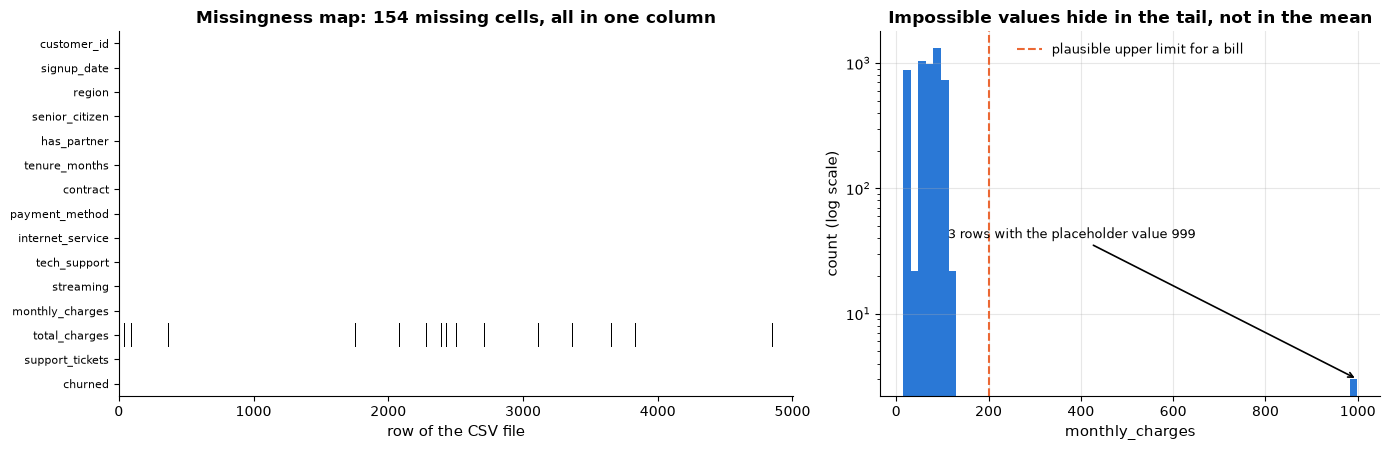

In [69]:
# .isna() is True for every missing cell; .to_numpy() turns the frame into an array; .T puts the columns on the y-axis
na = churn_raw.isna().to_numpy().T                       # (columns, rows): one pixel per cell
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), gridspec_kw={"width_ratios": [1.35, 1]})
# aspect="auto" stretches the pixels to fill the panel; with cmap="Greys" missing cells (True = 1) are black
axes[0].imshow(na, aspect="auto", cmap="Greys", vmin=0, vmax=1, interpolation="nearest")
axes[0].set_yticks(range(churn_raw.shape[1]), churn_raw.columns, fontsize=8)    # one tick per column, with its name
axes[0].set_xlabel("row of the CSV file")
axes[0].set_title(f"Missingness map: {na.sum()} missing cells, all in one column")   # True counts as 1 in a sum
axes[0].grid(False)

charges = churn_raw["monthly_charges"]                   # one column, as a Series
axes[1].hist(charges, bins=60, color=PALETTE[0])
axes[1].set_yscale("log")             # log counts make a handful of outliers visible next to thousands of normal rows
axes[1].axvline(200, color=PALETTE[1], ls="--", lw=1.5, label="plausible upper limit for a bill")
# (charges > 200).sum() counts the rows above the limit; the arrow points at the largest value
axes[1].annotate(f"{(charges > 200).sum()} rows with the placeholder value {charges.max():.0f}",
                 xy=(charges.max(), (charges > 200).sum()), xytext=(380, 40), ha="center", fontsize=9,
                 arrowprops={"arrowstyle": "->", "lw": 1.2})
axes[1].set_xlabel("monthly_charges")
axes[1].set_ylabel("count (log scale)")
axes[1].set_title("Impossible values hide in the tail, not in the mean")
axes[1].legend(loc="upper center", fontsize=9)
plt.tight_layout()
plt.show()

### 6.2 Selecting rows and columns: `[]`, `.loc`, `.iloc`

There are three ways to select, and the difference between them is worth memorising:

- `df["col"]` returns one column as a Series; `df[["col1", "col2"]]` a DataFrame.
- `df.loc[row_labels, column_labels]` selects **by label**, and accepts boolean masks.
  Slices with `.loc` are *inclusive* of the end label.
- `df.iloc[row_positions, column_positions]` selects **by integer position**, like NumPy.

A good row index is *unique*: `customer_id` should identify a customer. The raw file
contains a few exact duplicate rows (an export glitch), so we drop them first — otherwise
`set_index` succeeds but later operations that rely on unique labels fail with "cannot
reindex on an axis with duplicate labels".

In [70]:
# .duplicated() is True for every row that is an exact copy of an earlier row
print("exact duplicate rows in the raw file:", churn_raw.duplicated().sum())
# drop_duplicates() removes those copies; set_index("customer_id") turns that column into the row labels
df = churn_raw.drop_duplicates().set_index("customer_id")     # a meaningful row label; returns a new frame
print("index is unique:", df.index.is_unique, "| rows:", len(df))
# df["col"] returns one column as a Series; df[["a", "b"]] (a list of names) returns a DataFrame
print("one column        :", type(df["tenure_months"]).__name__, df["tenure_months"].shape)
print("several columns   :", type(df[["tenure_months", "monthly_charges"]]).__name__)
# .loc[row_label, column_label] selects by label
print("by label          :", df.loc["C00003", "contract"])
print("label slice       :", df.loc["C00001":"C00003", "tenure_months"].tolist(), "(inclusive of C00003)")
# .iloc[row_position, column_position] selects by integer position, exactly like NumPy indexing
print("by position       :", df.iloc[0, 5], "| first two rows, last three columns:")
print(df.iloc[:2, -3:])

exact duplicate rows in the raw file: 5
index is unique: True | rows: 5000
one column        : Series (5000,)
several columns   : DataFrame
by label          : Two year
label slice       : [17, 6, 8] (inclusive of C00003)
by position       : One year | first two rows, last three columns:
             total_charges  support_tickets  churned
customer_id                                         
C00001              880.42                0        0
C00002                 NaN                1        1


Filtering combines a boolean mask with `.loc` (or plain `[]`). Combine conditions with
`&`, `|`, `~` — *with parentheses*, because these operators bind tighter than comparisons.

In [71]:
# combine conditions with & (and), | (or), ~ (not); each comparison needs its own parentheses
mask = (df["contract"] == "Month-to-month") & (df["tenure_months"] < 6)
new_monthly = df.loc[mask, ["tenure_months", "monthly_charges", "churned"]]    # the masked rows, three columns
# the mean of a 0/1 column is the fraction of 1s (here the churn rate); :.1% formats it as a percentage
print(f"{mask.sum()} month-to-month customers with tenure < 6; churn rate among them: {new_monthly['churned'].mean():.1%}")
# .isin(list) is True where the value is one of the listed values
print("isin    :", df["payment_method"].isin(["Mailed check", "Electronic check"]).mean().round(3), "of customers pay by cheque")
# .between(a, b) is True where a <= value <= b
print("between :", df["monthly_charges"].between(50, 60).sum(), "customers pay between 50 and 60 per month")
# .query("...") filters rows with a condition written as a string that uses the column names directly
print("query   :", len(df.query("senior_citizen == 1 and internet_service == 'Fiber optic'")), "senior fibre customers")

420 month-to-month customers with tenure < 6; churn rate among them: 71.4%
isin    : 0.537 of customers pay by cheque
between : 632 customers pay between 50 and 60 per month
query   : 328 senior fibre customers


### 6.3 New columns, vectorised operations and missing values

Column arithmetic is vectorised exactly as in NumPy (pandas calls NumPy underneath).
`assign` adds columns and returns a *new* frame, which keeps code chainable; `df["new"] = ...`
modifies in place, which is fine too — but avoid the `inplace=True` keyword of other
methods (it hides the result, does not save memory, and is being phased out).

Missing values are represented by `NaN` (a floating-point "not a number"; text and
nullable columns may use `pd.NA`). `NaN` is not equal to anything, including itself, so
never test `== np.nan`: use `isna()` / `notna()`. Most reductions skip missing values
(`skipna=True`), which can hide how many there are — always count them.

In [72]:
# .assign(name=...) returns a copy of the frame with new (or replaced) columns
df = df.assign(
    charges_per_month=lambda d: d["total_charges"] / d["tenure_months"],      # lambda receives the frame built so far
    long_tenure=lambda d: d["tenure_months"] >= 24,                            # a True / False column
)
print("missing values per column (non-zero only):")
# .isna().sum() counts the missing values in each column; [lambda s: s > 0] keeps only the non-zero counts
print(df.isna().sum()[lambda s: s > 0])
print("\ntotal_charges is missing whenever tenure is 0 (no bill yet) plus a few random gaps:")
# pd.crosstab(a, b) counts how often each combination of the values of a and b occurs
print(pd.crosstab(df["tenure_months"] == 0, df["total_charges"].isna(), rownames=["tenure == 0"], colnames=["total_charges missing"]))
filled = df["total_charges"].fillna(0.0)                      # one strategy; notebook 4 discusses imputation properly
# .fillna(value) replaces every NaN with value; .mean() on its own skips NaN
print(f"\nmean total_charges: skipping NaN = {df['total_charges'].mean():.1f}, after fillna(0) = {filled.mean():.1f}")
# .dropna(subset=[...]) drops the rows that have a missing value in any of the listed columns
print("rows left after dropna(subset=['total_charges']):", len(df.dropna(subset=["total_charges"])))

missing values per column (non-zero only):
total_charges        154
charges_per_month    154
dtype: int64

total_charges is missing whenever tenure is 0 (no bill yet) plus a few random gaps:
total_charges missing  False  True 
tenure == 0                        
False                   4846    138
True                       0     16

mean total_charges: skipping NaN = 1984.1, after fillna(0) = 1923.0
rows left after dropna(subset=['total_charges']): 4846


### 6.4 `groupby`, `agg`, `pivot_table`

The **split–apply–combine** pattern: split the rows into groups by the value of one or more
columns, apply an aggregation to each group, combine the results into a new table. This is
the workhorse of exploratory analysis (notebook 3) and of target-oriented feature
engineering (notebook 4).

In [73]:
# .groupby("contract") splits the rows into one group per contract type;
# .agg(new_name=(column, function)) computes one summary per group and names the resulting column
by_contract = (df.groupby("contract")
                 .agg(customers=("churned", "size"),               # number of rows in the group
                      churn_rate=("churned", "mean"),              # fraction of customers who churned
                      median_tenure=("tenure_months", "median"),
                      mean_monthly=("monthly_charges", "mean"))
                 .sort_values("churn_rate", ascending=False))      # highest churn rate first
by_contract.round(3)

,customers,churn_rate,median_tenure,mean_monthly
contract,,,,
Month-to-month,2794,0.474,15.0,70.259
One year,1222,0.193,30.0,68.150
Two year,984,0.072,52.0,68.904


A three-row table is small enough to read, but the *shape* of the result is the point of
`groupby`, and a bar chart states it immediately: month-to-month customers churn several
times as often as customers on a two-year contract, even though all three groups pay almost
the same monthly bill — so the contract, not the price, is what separates them. Every
`groupby` result is a table, and every table is a candidate for a picture.

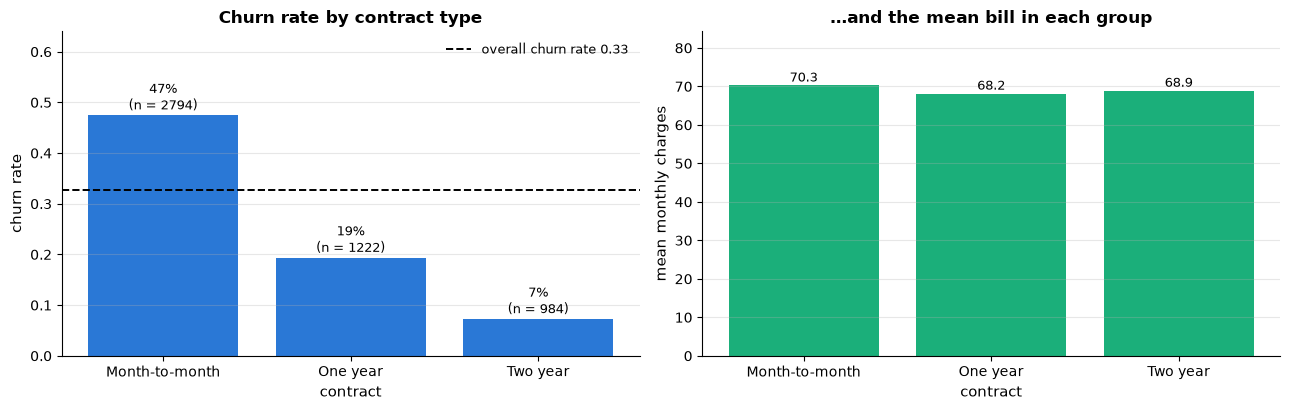

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharex=True)    # sharex: both panels use the same x-axis
order = by_contract.index.tolist()           # the contract names, in the sorted order of by_contract
axes[0].bar(order, by_contract["churn_rate"], color=PALETTE[0])   # vertical bar chart
# axhline draws a horizontal reference line across the panel, here at the overall churn rate
axes[0].axhline(df["churned"].mean(), color="black", ls="--", lw=1.4,
                label=f"overall churn rate {df['churned'].mean():.2f}")
for i, (rate, n) in enumerate(zip(by_contract["churn_rate"], by_contract["customers"])):
    axes[0].text(i, rate + 0.012, f"{rate:.0%}\n(n = {n})", ha="center", fontsize=9)   # label above each bar
axes[0].set_ylim(0, by_contract["churn_rate"].max() * 1.35)      # headroom for the labels
axes[0].set_ylabel("churn rate")
axes[0].set_title("Churn rate by contract type")
axes[0].legend(loc="upper right", fontsize=9)

axes[1].bar(order, by_contract["mean_monthly"], color=PALETTE[2])
for i, v in enumerate(by_contract["mean_monthly"]):
    axes[1].text(i, v + 1, f"{v:.1f}", ha="center", fontsize=9)
axes[1].set_ylim(0, by_contract["mean_monthly"].max() * 1.2)
axes[1].set_ylabel("mean monthly charges")
axes[1].set_title("…and the mean bill in each group")
for ax in axes:
    ax.set_xlabel("contract")
    ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

The "named aggregation" syntax `name=(column, function)` documents what each output
column is. Grouping by two keys gives a hierarchical index; `pivot_table` presents the same
information as a two-way table, which is easier to read (and to plot as a heatmap):

internet_service,DSL,Fiber optic,No
contract,,,
Month-to-month,0.348,0.696,0.225
One year,0.099,0.355,0.038
Two year,0.038,0.131,0.000


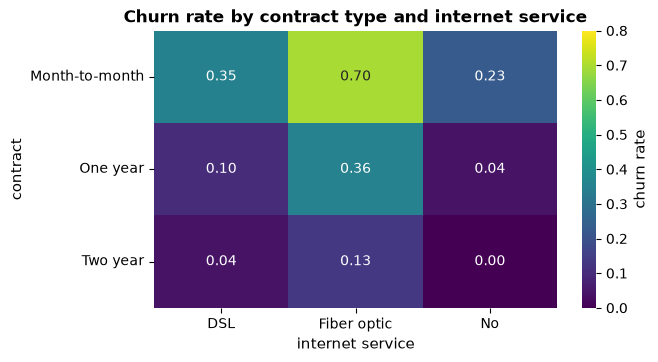

In [75]:
# pivot_table: one row per contract, one column per internet_service, each cell = mean of "churned" for that pair
rate_table = df.pivot_table(values="churned", index="contract", columns="internet_service", aggfunc="mean")
display(rate_table.round(3))       # display() renders a table even when it is not the last line of the cell

fig, ax = plt.subplots(figsize=(6.5, 3.6))
# seaborn's heatmap colours each cell by its value; annot=True writes the numbers in, fmt=".2f" with 2 decimals
sns.heatmap(rate_table, annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=0.8, ax=ax, cbar_kws={"label": "churn rate"})
ax.set_title("Churn rate by contract type and internet service")
ax.set_xlabel("internet service")
ax.set_ylabel("contract")
ax.tick_params(axis="y", rotation=0)     # keep the row labels horizontal
ax.grid(False)
plt.show()

### 6.5 Merging tables

Real projects join several tables — customers, invoices, support tickets. `pd.merge`
implements SQL-style joins (`how="inner" | "left" | "right" | "outer"`) on one or more key
columns. Two habits prevent most join bugs: state the expected cardinality with
`validate=` (pandas raises if a supposedly unique key is duplicated), and check the row
count before and after.

In [76]:
# a small lookup table: one row per region
regions = pd.DataFrame({"region": ["North", "South", "East", "West"],
                        "hub_city": ["Leeds", "Brighton", "Norwich", "Cardiff"],
                        "avg_speed_mbps": [72, 88, 61, 79]})
# reset_index() turns customer_id back into an ordinary column so it survives the merge.
# merge(..., on="region", how="left") keeps every customer and adds the matching region columns (NaN if no match);
# validate="many_to_one" raises an error if a region appeared more than once in the lookup table
merged = df.reset_index().merge(regions, on="region", how="left", validate="many_to_one")
print("rows before / after the left join:", len(df), "/", len(merged))
print("customers whose region did not match the lookup table:", merged["hub_city"].isna().sum())
# .unique() lists the distinct values; sorted() puts them in alphabetical order
print("unmatched region spellings:", sorted(merged.loc[merged["hub_city"].isna(), "region"].unique()))

rows before / after the left join: 5000 / 5000
customers whose region did not match the lookup table: 50
unmatched region spellings: ['east', 'north', 'south', 'west']


The join silently failed for 50 rows because their region is spelled in lower case — a
real-world data-quality issue that we will fix with vectorised string methods in section
8. Joins are unforgiving about exact key equality.

### 6.6 Dates and times

Datetime columns (`datetime64`) support arithmetic and expose calendar components through
the `.dt` accessor; subtracting two datetimes gives a `Timedelta`. Notebook 16 builds on
this for time-series work.

earliest / latest signup: 2018-07-03 / 2024-06-30
years covered: [2018, 2019, 2020, 2021, 2022, 2023, 2024]
days since signup vs. tenure in months — correlation: 0.9999


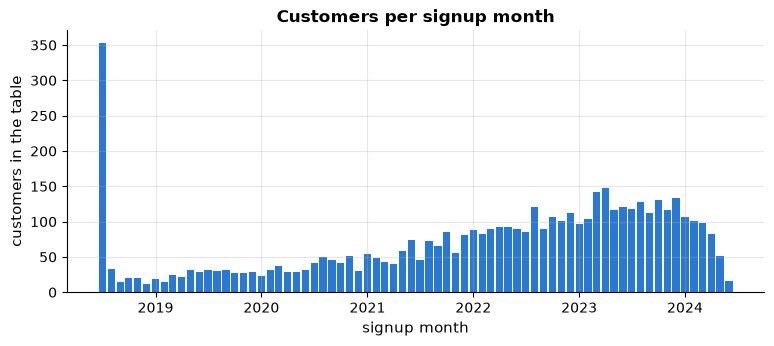

In [77]:
snapshot = pd.Timestamp("2024-06-30")                          # the date the table was extracted
signup = df["signup_date"]
# .min() / .max() give the earliest / latest timestamp; .date() drops the time of day
print("earliest / latest signup:", signup.min().date(), "/", signup.max().date())
# the .dt accessor exposes the parts of each date (.dt.year, .dt.month, .dt.day, ...)
print("years covered:", sorted(signup.dt.year.unique().tolist()))
days_since = (snapshot - signup).dt.days     # date minus date is a time span; .dt.days converts it to whole days
# np.corrcoef returns a 2 x 2 correlation matrix; [0, 1] is the correlation between the two inputs
print("days since signup vs. tenure in months — correlation:", np.corrcoef(days_since, df["tenure_months"])[0, 1].round(4))

# .dt.to_period("M") maps each date to its month; value_counts() counts rows per month; sort_index() orders the months
signups_per_month = signup.dt.to_period("M").value_counts().sort_index()
fig, ax = plt.subplots(figsize=(9, 3.4))
# .to_timestamp() turns the months back into dates matplotlib can place on a time axis; width=25 is in days
ax.bar(signups_per_month.index.to_timestamp(), signups_per_month.values, width=25, color=PALETTE[0])
ax.set_xlabel("signup month")
ax.set_ylabel("customers in the table")
ax.set_title("Customers per signup month")
plt.show()

The plot immediately shows something the summary statistics hid: a spike in the very first
month. It is an artefact of how the table was built — tenure is capped at 72 months, so
every customer who joined earlier is recorded as having signed up exactly 72 months before
the extraction date. Finding such things is what exploratory analysis (notebook 3) is for.

### 6.7 The categorical dtype

Text columns with few distinct values (contract type, region, payment method) are better
stored as `category`: pandas keeps an integer code per row and a small table of the
distinct values, which saves memory and makes group operations faster. An *ordered*
categorical additionally knows that `"Month-to-month" < "One year" < "Two year"`, so it sorts
and compares sensibly. Many scikit-learn encoders and `HistGradientBoosting*` (notebook 10)
recognise categorical columns automatically.

In [78]:
# memory_usage(deep=True) measures the stored strings themselves, not only the pointers to them
before = df["contract"].memory_usage(deep=True, index=False)
# pd.Categorical stores each value as a small integer code plus one shared list of categories;
# ordered=True means the categories have a meaningful order (Month-to-month < One year < Two year)
contract_cat = pd.Categorical(df["contract"], categories=["Month-to-month", "One year", "Two year"], ordered=True)
df = df.assign(contract=contract_cat)
after = df["contract"].memory_usage(deep=True, index=False)
print(f"memory for the contract column: {before / 1e3:.0f} kB as str -> {after / 1e3:.0f} kB as category")
# .cat.categories lists the allowed values; .cat.codes holds the integer code stored for each row
print("categories:", list(df["contract"].cat.categories), "| codes of the first rows:", df["contract"].cat.codes[:5].tolist())
# for an ordered categorical, comparisons such as >= follow the category order
print("ordered comparison — customers on at least a one-year contract:", (df["contract"] >= "One year").mean().round(3))

memory for the contract column: 97 kB as str -> 5 kB as category
categories: ['Month-to-month', 'One year', 'Two year'] | codes of the first rows: [1, 0, 2, 1, 0]
ordered comparison — customers on at least a one-year contract: 0.441


### 6.8 Method chaining

pandas methods return new objects, so an analysis can be written as one readable
**chain** that goes from raw data to result without intermediate variables. Wrap the chain in
parentheses to split it over lines, one method per line; `pipe(func)` inserts any function
into the chain. A chain that computes the churn rate per tenure bucket:

In [79]:
tenure_bins = [0, 6, 12, 24, 48, 72]           # bucket edges in months
# a method chain: each step works on the result of the previous one, so no intermediate variables are needed
churn_by_tenure = (
    churn_raw
    .drop_duplicates(subset="customer_id")                                        # remove the duplicated rows
    # pd.cut puts each value into an interval (0, 6], (6, 12], ...; include_lowest=True also puts 0 in the first one
    .assign(tenure_bucket=lambda d: pd.cut(d["tenure_months"], bins=tenure_bins, right=True, include_lowest=True))
    .groupby("tenure_bucket", observed=True)                                      # observed=True: only buckets that occur
    .agg(customers=("churned", "size"), churn_rate=("churned", "mean"))
    .assign(churn_rate=lambda d: d["churn_rate"].round(3))
)
churn_by_tenure

,customers,churn_rate
tenure_bucket,,
"(-0.001, 6.0]",572,0.671
"(6.0, 12.0]",725,0.441
"(12.0, 24.0]",1293,0.394
"(24.0, 48.0]",1471,0.225
"(48.0, 72.0]",939,0.094


The dependence of churn on tenure — an early-life spike followed by a steady decline — is
exactly the kind of structure the models of later notebooks must capture.

### 6.9 Pitfalls: chained assignment, copy-on-write, `object` columns

**Chained assignment.** `df[df["a"] > 0]["b"] = 1` looks like it sets `b` for the selected
rows. It does not: the first `[]` creates a temporary object, the assignment lands on that
temporary, and `df` is unchanged. Since pandas 3 the library follows **copy-on-write**
semantics — every selection behaves like an independent copy, and writing through a chain
raises a `ChainedAssignmentError` warning instead of silently doing nothing. The correct
form is a single `.loc` assignment.

In [80]:
import warnings          # standard-library module for raising and catching warnings

toy = pd.DataFrame({"a": [1, -1, 2], "b": [0, 0, 0]})
with warnings.catch_warnings(record=True) as caught:             # capture the warning so we can print it
    warnings.simplefilter("always")                                # report the warning even if it was shown before
    # toy[...] creates a new temporary frame, so the assignment changes that temporary and never reaches toy
    toy[toy["a"] > 0]["b"] = 1                                     # WRONG: chained assignment
print("after chained assignment, b =", toy["b"].tolist(), "| warning:", caught[0].category.__name__ if caught else "none")

toy.loc[toy["a"] > 0, "b"] = 1                                     # RIGHT: one .loc with the mask
print("after .loc assignment,      b =", toy["b"].tolist())

subset = toy[toy["a"] > 0]                                         # copy-on-write: subset is independent of toy
subset.loc[:, "b"] = 99
print("modifying the subset leaves toy untouched:", toy["b"].tolist())

after chained assignment, b = [0, 0, 0] | warning: ChainedAssignmentError
after .loc assignment,      b = [1, 0, 1]
modifying the subset leaves toy untouched: [1, 0, 1]


**`object` versus `str` columns.** Before pandas 3, text lived in `object` columns, which
could contain *anything* — strings, numbers and `None` mixed together — and every operation
on them was a slow Python loop. pandas 3 uses a proper string dtype (`str`), comparisons
with `==` and the `.str` accessor work as expected, and missing text is `NaN`. If you still
meet an `object` column (e.g. from an old pickle), convert it with `.astype("string")` or
`pd.to_numeric(..., errors="coerce")` for numbers-as-text.

**Copies.** `df2 = df` does *not* copy; both names refer to the same frame. Use
`df.copy()` when you want an independent object to modify.

## 7. From DataFrame to model input

Every scikit-learn estimator expects a feature matrix `X` of shape `(n_samples, n_features)`
— numeric, no missing values (with a few exceptions) — and a target `y` of shape
`(n_samples,)`. The path from a table to that pair has three steps: choose the target
column, choose (and later engineer) the feature columns, and split into training and test
data *before* anything else is fitted. Here we take only the numeric columns and fill the
gaps with the median so that we can see the shapes; the correct, leakage-free way to
handle encoding, imputation and scaling — inside a `Pipeline` — is the subject of notebooks
4 and 5.

In [81]:
from sklearn.model_selection import train_test_split

# drop repeated customers; reset_index(drop=True) renumbers the rows 0..n-1 and discards the old index
data = churn_raw.drop_duplicates(subset="customer_id").reset_index(drop=True)
numeric_features = ["tenure_months", "monthly_charges", "total_charges", "support_tickets",
                    "senior_citizen", "has_partner", "tech_support", "streaming"]
# fill each column's missing values with that column's median
X = data[numeric_features].fillna(data[numeric_features].median())    # a stop-gap; notebook 4 does this inside a pipeline
y = data["churned"]                                                     # the target: 1 = churned, 0 = stayed
print("X:", type(X).__name__, X.shape, "| y:", type(y).__name__, y.shape, "| positive rate:", y.mean().round(3))

# hold out 20 % of the rows as a test set; stratify=y keeps the churn rate equal in both parts,
# random_state makes the random shuffle reproducible
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print("train:", X_train.shape, f"churn rate {y_train.mean():.3f}", "| test:", X_test.shape, f"churn rate {y_test.mean():.3f}")
print("as NumPy:", X_train.to_numpy().shape, X_train.to_numpy().dtype)    # .to_numpy() gives the underlying array

# a minimal model, only to show that the shapes fit together (notebooks 5 and 7 explain what the numbers mean)
from sklearn.dummy import DummyClassifier             # a baseline that ignores the features
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline            # chains steps so they are fitted and applied together
from sklearn.preprocessing import StandardScaler      # rescales each feature to mean 0 and standard deviation 1

# strategy="most_frequent" always predicts the most common class seen in y_train
baseline = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
# .fit() learns from the training data: first the scaler's means and stds, then the logistic regression's weights
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(X_train, y_train)
# .score(X, y) of a classifier is its accuracy: the fraction of rows predicted correctly
print(f"\nmajority-class baseline accuracy: {baseline.score(X_test, y_test):.3f}")
print(f"logistic regression accuracy    : {model.score(X_test, y_test):.3f}   (numeric features only, no tuning)")

X: DataFrame (5000, 8) | y: Series (5000,) | positive rate: 0.326
train: (4000, 8) churn rate 0.327 | test: (1000, 8) churn rate 0.326
as NumPy: (4000, 8) float64

majority-class baseline accuracy: 0.674
logistic regression accuracy    : 0.768   (numeric features only, no tuning)


Those two statements — the split into `X`/`y` and the split into train/test — are the whole
interface between a table and a model, so here they are as a diagram. The left panel takes
the columns of the table apart: eight numeric columns become the feature matrix, one column
becomes the target, and the rest are left behind (identifiers, dates and text columns that
notebook 4 will encode). The right panel cuts the *rows* in two, keeping the proportion of
churners the same in both halves — that is what `stratify=y` buys.

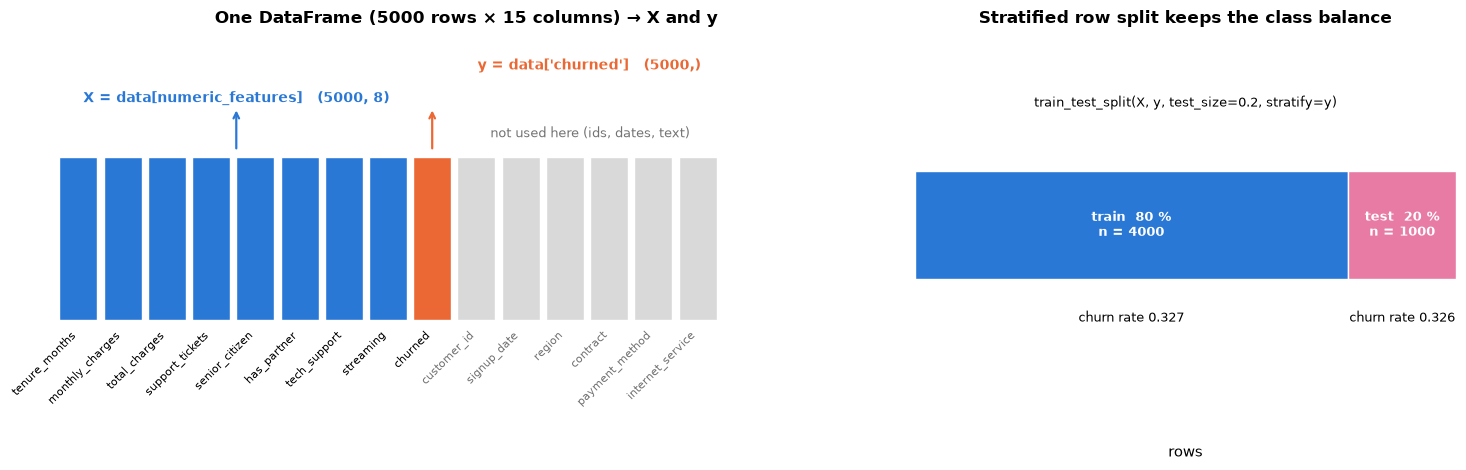

In [82]:
used = numeric_features + ["churned"]
left_out = [c for c in data.columns if c not in used]            # every column the model does not use
all_cols = numeric_features + ["churned"] + left_out
# blue for the features, orange for the target, light grey for the unused columns
colour_of = {c: (PALETTE[0] if c in numeric_features else PALETTE[1] if c == "churned" else "0.85")
             for c in all_cols}

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8), gridspec_kw={"width_ratios": [1.6, 1]})
# --- left: one coloured block per column of `data`, with its name underneath (rotated so long names fit)
for j, col in enumerate(all_cols):
    axes[0].add_patch(plt.Rectangle((j, 0), 0.86, 3, facecolor=colour_of[col], edgecolor="white"))
    axes[0].text(j + 0.43, -0.18, col, rotation=45, ha="right", va="top", fontsize=8,
                 color="black" if colour_of[col] != "0.85" else "0.45")
# arrows and labels marking which columns become X and which becomes y
axes[0].annotate("", xy=(len(numeric_features) / 2, 3.9), xytext=(len(numeric_features) / 2, 3.1),
                 arrowprops={"arrowstyle": "->", "lw": 1.6, "color": PALETTE[0]})
axes[0].text(len(numeric_features) / 2, 4.0, f"X = data[numeric_features]   {X.shape}",
             ha="center", fontsize=10, color=PALETTE[0], fontweight="bold")
axes[0].annotate("", xy=(len(numeric_features) + 0.43, 3.9), xytext=(len(numeric_features) + 0.43, 3.1),
                 arrowprops={"arrowstyle": "->", "lw": 1.6, "color": PALETTE[1]})
axes[0].text(len(all_cols) - 0.5, 4.6, f"y = data['churned']   {y.shape}",
             ha="right", fontsize=10, color=PALETTE[1], fontweight="bold")
axes[0].text(len(numeric_features) + 1 + len(left_out) / 2, 3.3, "not used here (ids, dates, text)",
             ha="center", va="bottom", fontsize=9, color="0.45")
axes[0].set_xlim(-0.6, len(all_cols) + 4.0)
axes[0].set_ylim(-2.2, 5.3)
axes[0].set_title(f"One DataFrame ({data.shape[0]} rows × {data.shape[1]} columns) → X and y")

# --- right: the train/test split drawn as one horizontal bar made of two segments
shares = [len(X_train), len(X_test)]
starts = [0, len(X_train)]
for (label, start, width, colour, rate) in [("train  80 %", 0, shares[0], PALETTE[0], y_train.mean()),
                                            ("test  20 %", starts[1], shares[1], PALETTE[4], y_test.mean())]:
    axes[1].barh(0, width, left=start, height=0.5, color=colour, edgecolor="white")   # left= is where the bar starts
    axes[1].text(start + width / 2, 0, f"{label}\nn = {width}", ha="center", va="center",
                 color="white", fontweight="bold", fontsize=9)
    axes[1].text(start + width / 2, -0.45, f"churn rate {rate:.3f}", ha="center", fontsize=9)
axes[1].text(len(X) / 2, 0.55, "train_test_split(X, y, test_size=0.2, stratify=y)", ha="center", fontsize=9.5)
axes[1].set_xlim(0, len(X))
axes[1].set_ylim(-1.0, 0.9)
axes[1].set_xlabel("rows")
axes[1].set_title("Stratified row split keeps the class balance")

for ax in axes:
    ax.set_yticks([])
    ax.set_xticks([])
    ax.grid(False)
    for spine in ax.spines.values():        # a diagram needs no axes frame
        spine.set_visible(False)
plt.tight_layout()
plt.show()

scikit-learn accepts DataFrames directly (and remembers the column names in
`feature_names_in_`), so `to_numpy()` is rarely necessary at the model boundary; it *is*
the right move when you want to do heavy numerical work on the values yourself. The
logistic regression beats the majority-class baseline by about ten accuracy points using
numeric columns alone; whether that is good, and how to do better, is the business of
notebooks 4–7.

## 8. Performance notes

The single most important rule: **never iterate over the rows of a DataFrame in Python if
a vectorised expression exists.** `df.iterrows()` builds a Series object for every row —
on our 5 000-row table that costs of the order of a hundred milliseconds where the vectorised
computation costs of the order of a hundred *microseconds*; on a million rows it is the difference
between one second and a coffee break. `apply(axis=1)` is only slightly better: it still
calls a Python function once per row.

all methods agree: True
total_via_iterrows        87.831 ms
total_via_apply           20.682 ms
total_vectorised           0.100 ms
total_numpy                0.039 ms


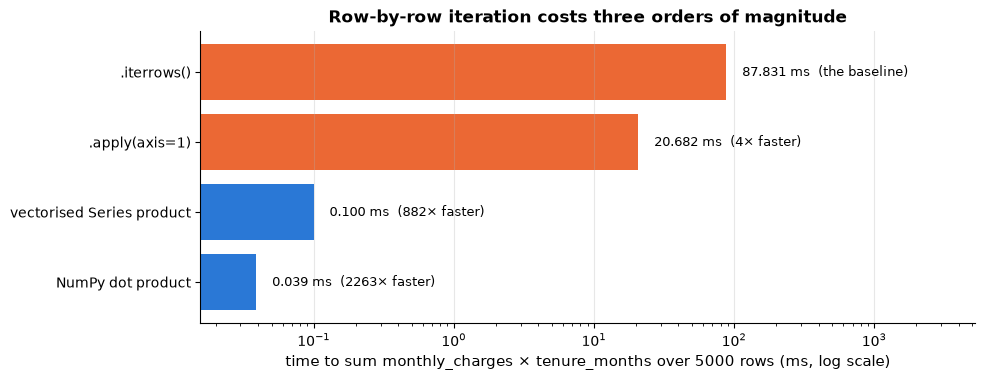

In [83]:
def total_via_iterrows(frame):
    """Sum of monthly_charges * tenure_months over all rows, looping with .iterrows() (slowest)."""
    total = 0.0
    for _, row in frame.iterrows():          # yields (index label, row as a Series) one row at a time
        total += row["monthly_charges"] * row["tenure_months"]
    return total

def total_via_apply(frame):
    """Same total; .apply(axis=1) calls the lambda once per row, so it is still a Python loop in disguise."""
    return frame.apply(lambda row: row["monthly_charges"] * row["tenure_months"], axis=1).sum()

def total_vectorised(frame):
    """Same total; multiplies the two columns as whole Series in one vectorised operation."""
    return (frame["monthly_charges"] * frame["tenure_months"]).sum()

def total_numpy(frame):
    """Same total as a NumPy dot product (a @ b = sum of a[i] * b[i]): the fastest version."""
    return frame["monthly_charges"].to_numpy() @ frame["tenure_months"].to_numpy()

row_funcs = [total_via_iterrows, total_via_apply, total_vectorised, total_numpy]
results = {f.__name__: f(data) for f in row_funcs}     # dict comprehension: function name -> its result
print("all methods agree:", np.allclose(list(results.values()), results["total_numpy"]))
# `f=f` freezes the current f inside each lambda (without it, every lambda would use the last f of the loop)
row_times = [time_ms(lambda f=f: f(data), repeats=3) for f in row_funcs]
for f, t in zip(row_funcs, row_times):
    print(f"{f.__name__:22s} {t:9.3f} ms")

fig, ax = plt.subplots(figsize=(10, 3.8))
names = [".iterrows()", ".apply(axis=1)", "vectorised Series product", "NumPy dot product"]
ax.barh(names, row_times, color=[PALETTE[1], PALETTE[1], PALETTE[0], PALETTE[0]])
for i, t in enumerate(row_times):
    speedup = "the baseline" if i == 0 else f"{row_times[0] / t:.0f}× faster"     # speed-up relative to .iterrows()
    ax.text(t * 1.3, i, f"{t:.3f} ms  ({speedup})", va="center", fontsize=9)
ax.set_xscale("log")
ax.set_xlim(min(row_times) * 0.4, max(row_times) * 60)
ax.invert_yaxis()
ax.set_xlabel(f"time to sum monthly_charges × tenure_months over {len(data)} rows (ms, log scale)")
ax.set_title("Row-by-row iteration costs three orders of magnitude")
ax.grid(axis="y", visible=False)
plt.show()

**Strings.** The `.str` accessor applies a string method to a whole column at once
(`.str.lower()`, `.str.strip()`, `.str.contains(pattern)`, `.str.split(...)`,
`.str.replace(...)`, `.str.len()`), which is both faster and clearer than a loop. Here it
fixes the inconsistent region spelling that broke our join:

In [84]:
print("distinct spellings before:", sorted(data["region"].unique()))
# the .str accessor applies a string method to every value: .strip() removes surrounding whitespace,
# .title() capitalises the first letter of each word ("north" -> "North")
data = data.assign(region=data["region"].str.strip().str.title())
print("distinct spellings after :", sorted(data["region"].unique()))
# .str.contains(text, case=False) is True where the value contains "check", ignoring upper/lower case
print("customers paying by some kind of cheque:", data["payment_method"].str.contains("check", case=False).sum())

distinct spellings before: ['East', 'North', 'South', 'West', 'east', 'north', 'south', 'west']
distinct spellings after : ['East', 'North', 'South', 'West']
customers paying by some kind of cheque: 2687


**Other habits that pay off.**

- `df.eval("charges_per_month = total_charges / tenure_months")` evaluates a column
  expression as a string; with the optional `numexpr` package it avoids temporaries and is
  faster on large frames. It is a convenience, not a necessity.
- Drop to NumPy (`.to_numpy()`) for heavy numerical loops, matrix algebra or anything you
  will call thousands of times: pandas adds bookkeeping overhead per operation (index
  alignment, dtype checks) that is negligible for a few big operations and dominant for
  many tiny ones.
- Store low-cardinality text as `category`, and downcast floats to `float32` when memory
  matters (`pd.to_numeric(..., downcast="float")`).
- Read only what you need (`usecols=`) and, for files larger than memory, process them in
  `chunksize` pieces or switch to a columnar format (Parquet) — notebook 18 discusses
  scaling.

## Summary

- **NumPy arrays** are contiguous, homogeneous blocks of numbers; vectorised operations run
  in C and are 10–100× faster than Python loops. Know your `shape` and `dtype`.
- **Indexing**: slices are *views*, boolean/fancy indexing gives *copies*; `axis=k` collapses
  axis $k$; `x[:, None]` turns `(n,)` into `(n, 1)`.
- **Broadcasting** aligns shapes from the right (equal or 1); it gives loop-free
  standardisation, outer products and distance matrices — and the `(n,)` vs. `(n, 1)` trap.
- **Linear algebra**: `@` for products, `solve` instead of `inv`, `lstsq` for least squares,
  `eigh` for symmetric matrices, `svd` for everything else.
- **Randomness**: one seeded `np.random.default_rng` object, passed explicitly; `permutation`
  for shuffling, `choice(replace=True)` for bootstrapping.
- **pandas**: labelled, index-aligned tables; `loc`/`iloc` for selection, boolean masks
  for filtering, `assign` and chaining for transformations, `groupby`/`agg`/`pivot_table`
  for summaries, `merge` for joins, `.dt` and `.str` accessors, `category` dtype.
- **Model input**: `X` is `(n, d)` numeric, `y` is `(n,)`; split with
  `train_test_split(..., stratify=y)` before fitting anything.
- **Performance**: vectorise; never `iterrows`; assign with a single `.loc`; use `.str`
  methods; drop to NumPy for heavy numerics.

| Task | Idiom |
|---|---|
| per-feature statistic | `X.mean(axis=0)` → shape `(d,)` |
| standardise columns | `(X - X.mean(0)) / X.std(0)` |
| add an axis | `x[:, None]`, `np.newaxis`, `keepdims=True` |
| pairwise distances | `np.sqrt(((X[:, None] - Y[None]) ** 2).sum(-1))` or `scipy.spatial.distance.cdist` |
| solve / least squares | `np.linalg.solve(A, b)`, `np.linalg.lstsq(X, y, rcond=None)` |
| reproducible randomness | `rng = np.random.default_rng(42)`; `rng.normal`, `rng.permutation`, `rng.choice` |
| select rows/columns | `df.loc[mask, ["a", "b"]]`, `df.iloc[:5, -3:]` |
| new column, chainable | `df.assign(c=lambda d: d["a"] / d["b"])` |
| group summary | `df.groupby("k").agg(n=("y", "size"), rate=("y", "mean"))` |
| two-way table | `df.pivot_table(values="y", index="a", columns="b", aggfunc="mean")` |
| join | `left.merge(right, on="key", how="left", validate="many_to_one")` |
| dates, strings | `s.dt.year`, `(t1 - t0).dt.days`, `s.str.lower()`, `s.str.contains("x")` |
| to scikit-learn | `X = df[features]`, `y = df["target"]`, `train_test_split(X, y, stratify=y)` |

**Next steps:** notebook 2 (mathematics essentials) gives the linear algebra, calculus and
probability behind the operations used here; notebook 3 (exploratory data analysis) puts
the pandas toolkit to work on the churn data; notebook 4 (preprocessing) turns the raw table
into a clean, model-ready matrix inside a pipeline.

## Exercises

### Exercise 1 — Broadcasting puzzle (easy)
Without running the code, predict the output shape of each expression for
`A = np.ones((4, 1, 3))`, `B = np.ones((5, 3))`, `c = np.ones(3)`, `d = np.ones(4)`:
(a) `A + B`, (b) `A * c`, (c) `B + c`, (d) `B + d`, (e) `B + d[:, None]`,
(f) `A + d[:, None, None]`. Then check your answers.

<details><summary>Solution sketch</summary>

(a) `(4, 5, 3)`; (b) `(4, 1, 3)`; (c) `(5, 3)`; (d) `ValueError` — `(5, 3)` vs `(4,)` →
`(1, 4)`: 3 ≠ 4; (e) also a `ValueError` — `(5, 3)` vs `(4, 1)`: 5 ≠ 4; (f) `(4, 1, 3)`,
since `(4, 1, 1)` stretches along the last axis. Rule: align from the right, each pair equal
or 1.
</details>

### Exercise 2 — Groupby analytics on the churn data (easy)
Using `churn_raw` (deduplicated on `customer_id`), compute for each combination of
`payment_method` and `senior_citizen`: the number of customers, the churn rate, and the
mean number of support tickets. Present it as a pivot table of churn rates with payment
methods as rows and `senior_citizen` as columns, and plot it as a heatmap. Which segment
churns most?

<details><summary>Solution sketch</summary>

```py
seg = (churn_raw.drop_duplicates("customer_id")
         .groupby(["payment_method", "senior_citizen"])
         .agg(n=("churned", "size"), churn_rate=("churned", "mean"), tickets=("support_tickets", "mean")))
seg["churn_rate"].unstack("senior_citizen")   # or df.pivot_table(values="churned", index=..., columns=..., aggfunc="mean")
```
Senior citizens paying by electronic check have the highest churn rate; the base rate in
the data is about 33 %.
</details>

### Exercise 3 — Standardisation and distances from scratch (medium)
Write `standardise(X)` that returns `(X_std, mean, std)` using broadcasting, and
`pairwise_sq_dist(X)` that returns the `(n, n)` matrix of *squared* Euclidean distances
between the rows of `X` using the identity $\|\mathbf{x}_i - \mathbf{x}_j\|^2 =
\|\mathbf{x}_i\|^2 + \|\mathbf{x}_j\|^2 - 2\,\mathbf{x}_i^\top\mathbf{x}_j$. Check both
against `sklearn.preprocessing.StandardScaler` and
`sklearn.metrics.pairwise.euclidean_distances(X, squared=True)` with `np.allclose`. Why must
you clip tiny negative values before taking a square root?

<details><summary>Solution sketch</summary>

```py
def pairwise_sq_dist(X):
    sq = (X ** 2).sum(axis=1)
    return np.maximum(sq[:, None] + sq[None, :] - 2 * X @ X.T, 0)
```
The diagonal should be exactly zero but round-off can give values like `-1e-13`, whose
square root is `NaN`; hence the clip.
</details>

### Exercise 4 — Bootstrap confidence interval (medium)
Take `monthly_charges` of the deduplicated churn data after replacing values above 200 by
`NaN` and dropping them. Compute a 95 % bootstrap percentile interval for the mean with
`rng.choice` (2 000 resamples), and compare it with the normal-approximation interval
$\bar{x} \pm 1.96\, s/\sqrt{n}$. Then do the same for the *median*. For which statistic does
the normal formula not apply, and why is the bootstrap still fine?

<details><summary>Solution sketch</summary>

The two intervals for the mean agree closely ($n \approx 5000$ is large). There is no
simple standard-error formula for the median; the bootstrap does not need one — it only
requires the ability to recompute the statistic on resamples. Notebook 2 treats the
bootstrap formally.
</details>

### Exercise 5 — Views, copies and the index (medium)
(a) Create `a = np.arange(12).reshape(3, 4)`, take `r = a[1]` and `f = a[[1]]`, set both to
zero, and explain what happened to `a`. (b) Build two Series `prices` (indexed by product
ID) and `quantities` (the same IDs in a different order plus one extra ID), multiply them,
and explain every `NaN`. (c) Rewrite `for i, row in df.iterrows(): df.loc[i, "x"] = row["a"] * 2`
as a single vectorised statement.

<details><summary>Solution sketch</summary>

(a) `r` is a view: row 1 of `a` becomes zero; `f` is a fancy-index copy: `a` is unchanged
by zeroing it. (b) Multiplication aligns on the index; the extra ID has no price → `NaN`.
(c) `df["x"] = df["a"] * 2` (or `df = df.assign(x=lambda d: d["a"] * 2)`).
</details>

## References and further reading

### Textbooks

- McKinney, W. (2022). *Python for Data Analysis* (3rd ed.). O'Reilly. (free at https://wesmckinney.com/book/) — Written by the creator of pandas; chapters 4 (NumPy basics), 5 (pandas), 7 (data cleaning), 10 (aggregation) and 11 (time series) cover this notebook in depth.
- VanderPlas, J. (2023). *Python Data Science Handbook* (2nd ed.). O'Reilly. (free at https://jakevdp.github.io/PythonDataScienceHandbook/) — Part 2 (NumPy) has the clearest explanation of broadcasting and fancy indexing anywhere; part 3 (pandas) covers alignment, groupby and pivot tables.
- Boyd, S., & Vandenberghe, L. (2018). *Introduction to Applied Linear Algebra: Vectors, Matrices, and Least Squares*. Cambridge University Press. (free) — Chapters 12–13 explain least squares and the normal equations used in section 4.2.
- Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3rd ed.). O'Reilly. — Chapter 2 walks through a pandas-to-scikit-learn workflow end to end.

### Papers

- Harris, C. R., et al. (2020). Array programming with NumPy. *Nature*, 585, 357–362. — The design of NumPy: the ndarray, strides, broadcasting, and the ecosystem built on it.
- McKinney, W. (2010). Data structures for statistical computing in Python. *Proceedings of the 9th Python in Science Conference*, 56–61. — The original pandas paper; short, and explains why index alignment is the central idea.
- Virtanen, P., et al. (2020). SciPy 1.0: fundamental algorithms for scientific computing in Python. *Nature Methods*, 17, 261–272. — SciPy provides `cdist`, `hilbert` and the optimisation and statistics routines used from notebook 2 on.
- Efron, B. (1979). Bootstrap methods: another look at the jackknife. *The Annals of Statistics*, 7(1), 1–26. — The bootstrap, previewed in section 5.
- Kluyver, T., et al. (2016). Jupyter Notebooks — a publishing format for reproducible computational workflows. In *Positioning and Power in Academic Publishing*, IOS Press, 87–90.

### Documentation and online resources (all free)

- NumPy user guide, *NumPy: the absolute basics for beginners* and *Broadcasting* — https://numpy.org/doc/stable/user/absolute_beginners.html and https://numpy.org/doc/stable/user/basics.broadcasting.html — The broadcasting page contains the formal rule with pictures.
- NumPy reference, *Random Generator* — https://numpy.org/doc/stable/reference/random/generator.html — Why `default_rng` replaced the legacy `np.random.*` functions.
- pandas user guide, *Indexing and selecting data*, *Group by: split-apply-combine*, *Copy-on-Write* — https://pandas.pydata.org/docs/user_guide/ — The copy-on-write page explains the pandas 3 semantics behind section 6.9.
- pandas, *10 minutes to pandas* — https://pandas.pydata.org/docs/user_guide/10min.html — A quick tour if you need one before starting.
- scikit-learn user guide, *Dataset loading utilities* and the glossary entry on the `X`/`y` convention — https://scikit-learn.org/stable/datasets.html and https://scikit-learn.org/stable/glossary.html